# 3D Convolutional Neural Network from Scratch

A 2D convolution slides a small square of weights across an image. A 3D convolution slides a small
cube across a volume, so it looks at a patch that has extent in three directions at once. The extra
axis only earns its place if the data really is arranged so that neighbouring positions along all
three axes belong together.

The dataset used here is **Statlog (Landsat Satellite)**. Every row of it is already a volume. Each
row holds 36 numbers that are a $3\times3$ neighbourhood of pixels from a satellite image, with
each of those 9 pixels recorded in 4 spectral bands, and the label is the ground cover of the
centre pixel. Reshaped, one row is

$$(\text{row},\ \text{column},\ \text{band}) = (3,\ 3,\ 4)$$

Two of those axes are spatial and the third is wavelength. Nothing had to be invented to produce
the third axis: it is in the sensor. Landsat MSS records four images of the same scene at once,
two in the visible range and two in the near infra-red, and the four values for a given pixel are
that pixel's reflectance in each. A $2\times2\times2$ filter sliding through the volume therefore
sees two neighbouring image rows, two neighbouring image columns and two neighbouring bands
together, and can respond to something like *this pair of adjacent pixels is brighter in the
infra-red than in the visible*. That is a joint spatial-spectral pattern, and classifying
multispectral cubes this way is the standard use of 3D convolution in remote sensing.

The network built here is:

```
(3, 3, 4) volume
  -> convolution, 16 filters of 2x2x2  -> (2, 2, 3, 16)
  -> ReLU
  -> flatten                           -> 192
  -> dense layer                       -> 6
  -> softmax
```

The volume is small - 36 numbers - so this supports one 3D convolution and not a deep stack of
them. That is enough to show the operation and its backward pass working on data that is genuinely
three dimensional, which is the point. There is no pooling layer, for a reason given below.

Everything - the convolution, the ReLU, the softmax, and every derivative - is written with NumPy
arrays and loops.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green = '#2a78d6', '#eb6834', '#1baf7a'

notebook_started = time.time()

## Loading the data

`fetch_ucirepo(id=146)` downloads the Statlog Landsat Satellite data: 6,435 rows of 36 integer
pixel values in the range 0-255, each with one of six ground cover labels.

The labels are coded 1, 2, 3, 4, 5 and 7. There is no class 6 - the original coding reserved it for
a mixture class that has no examples here - so the codes are mapped onto 0-5 with `np.searchsorted`
before anything else happens. The cell prints the raw counts and the majority class baseline, which
is the accuracy of always answering with the commonest label and the number the network has to
beat.

In [2]:
landsat = fetch_ucirepo(id=146)

raw = landsat.data.features.values.astype(float)
codes_raw = landsat.data.targets.values.ravel().astype(int)

class_codes = np.array([1, 2, 3, 4, 5, 7])
class_names = ['red soil', 'cotton crop', 'grey soil',
               'damp grey soil', 'stubble', 'very damp grey soil']

labels = np.searchsorted(class_codes, codes_raw)

print('rows and columns:', raw.shape)
print('pixel values run from', raw.min(), 'to', raw.max())
print()
print(f'{"code":>5s} {"class":22s} {"count":>6s}')
for k in range(6):
    print(f'{class_codes[k]:5d} {class_names[k]:22s} {(labels == k).sum():6d}')
print()
print('note there is no class 6 in this dataset')
print(f'majority class baseline: {np.bincount(labels).max() / len(labels):.4f}')

rows and columns: (6435, 36)
pixel values run from 27.0 to 157.0

 code class                   count
    1 red soil                 1533
    2 cotton crop               703
    3 grey soil                1358
    4 damp grey soil            626
    5 stubble                   707
    7 very damp grey soil      1508

note there is no class 6 in this dataset
majority class baseline: 0.2382


## Verifying the column layout

The 36 columns are unnamed - `Attribute1` to `Attribute36` - so before reshaping anything into a
volume the layout has to be established. The documented ordering is that the 9 pixels of the
neighbourhood are listed left to right and top to bottom, and within each pixel the 4 bands are
listed together, so band varies fastest:

$$\text{column } j \;\longrightarrow\; \text{pixel } p = \lfloor j/4 \rfloor,\qquad
\text{band } b = j \bmod 4$$

That is checked against the data rather than assumed. Two orderings are compared: **band fastest**
(the documented one, column $j$ is pixel $\lfloor j/4\rfloor$ band $j \bmod 4$) and **pixel
fastest** (column $j$ is band $\lfloor j/9\rfloor$ pixel $j \bmod 9$). For each, the 36x36
correlation matrix over the whole dataset is split into three groups of off-diagonal entries: pairs
of columns the ordering says are the same pixel in different bands, pairs it says are the same band
at different pixels, and pairs that share neither.

The signature to look for is that both *same-pixel* and *same-band* groups stand apart from the
*neither* group. An ordering that is wrong scrambles columns between the groups and all three
averages collapse towards each other.

In [3]:
correlation = np.corrcoef(raw.T)
off_diagonal = ~np.eye(36, dtype=bool)


def group_means(pixel_of, band_of):
    same_pixel = (pixel_of[:, None] == pixel_of[None, :]) & off_diagonal
    same_band = (band_of[:, None] == band_of[None, :]) & off_diagonal
    neither = off_diagonal & ~same_pixel & ~same_band
    return (correlation[same_pixel].mean(),
            correlation[same_band].mean(),
            correlation[neither].mean())


column = np.arange(36)
band_fastest = group_means(column // 4, column % 4)
pixel_fastest = group_means(column % 9, column // 9)

print(f'{"ordering":16s} {"same pixel":>12s} {"same band":>12s} {"neither":>12s}')
print(f'{"band fastest":16s} {band_fastest[0]:12.4f} {band_fastest[1]:12.4f} {band_fastest[2]:12.4f}')
print(f'{"pixel fastest":16s} {pixel_fastest[0]:12.4f} {pixel_fastest[1]:12.4f} {pixel_fastest[2]:12.4f}')

ordering           same pixel    same band      neither
band fastest           0.3255       0.8845       0.2835
pixel fastest          0.2785       0.4078       0.4483


Band fastest separates cleanly: columns it calls the same band at different pixels correlate at
0.88, far above the 0.28 of unrelated pairs, which is exactly what neighbouring pixels of the same
image should do. Pixel fastest does not separate at all - its *neither* group correlates more
strongly (0.45) than either of its supposedly related groups, which is incoherent. The documented
ordering is the right one.

Two further checks follow from it. Under band fastest, columns 0, 4, 8, ..., 32 are the nine pixels
in one band, and if those nine really are a $3\times3$ neighbourhood read row by row then
correlation between two of them should fall as the distance between their grid positions rises. The
cell below groups the pairs by Euclidean distance on a row-major $3\times3$ grid and averages.

The second check is which pixel is the centre. The label describes the centre pixel, so the centre
pixel's bands should be the most informative about it. Informativeness is measured with the
one-way F-ratio

$$F_j = \frac{\sum_c n_c (\bar{x}_{c,j} - \bar{x}_j)^2 / (C-1)}
              {\sum_c \sum_{i \in c} (x_{i,j} - \bar{x}_{c,j})^2 / (n - C)}$$

which is how far the class means of column $j$ are spread apart relative to the scatter inside the
classes. Each pixel's four F-ratios are averaged and laid out on the row-major grid.

In [4]:
pixel_of_column = np.arange(36) // 4
band_of_column = np.arange(36) % 4

grid_row, grid_col = np.divmod(np.arange(9), 3)
grid_distance = np.sqrt((grid_row[:, None] - grid_row[None, :]) ** 2 +
                        (grid_col[:, None] - grid_col[None, :]) ** 2)

band0 = np.where(band_of_column == 0)[0]
spatial = correlation[np.ix_(band0, band0)]

print('band 0, correlation against row-major 3x3 grid distance')
print(f'{"distance":>9s} {"pairs":>6s} {"mean corr":>10s}')
for value in np.unique(np.round(grid_distance, 4)):
    picked = (np.round(grid_distance, 4) == value) & ~np.eye(9, dtype=bool)
    if picked.sum():
        print(f'{value:9.3f} {picked.sum():6d} {spatial[picked].mean():10.4f}')

grand_mean = raw.mean(axis=0)
between = np.zeros(36)
within = np.zeros(36)
for k in range(6):
    group = raw[labels == k]
    between += len(group) * (group.mean(axis=0) - grand_mean) ** 2
    within += ((group - group.mean(axis=0)) ** 2).sum(axis=0)

f_ratio = (between / 5) / (within / (len(raw) - 6))
per_pixel = np.array([f_ratio[pixel_of_column == p].mean() for p in range(9)])

print()
print('mean F-ratio per pixel, laid out row-major:')
print(np.round(per_pixel.reshape(3, 3), 1))
print()
print('largest is pixel', int(per_pixel.argmax()), '- columns 16 to 19')

band 0, correlation against row-major 3x3 grid distance
 distance  pairs  mean corr
    1.000     24     0.9440
    1.414     16     0.9136
    2.000     12     0.8687
    2.236     16     0.8526
    2.828      4     0.8113

mean F-ratio per pixel, laid out row-major:
[[2403.7 2699.2 2413.2]
 [2980.3 3611.2 3102.3]
 [2369.3 2708.8 2486.2]]

largest is pixel 4 - columns 16 to 19


Both checks pass. Correlation falls monotonically with row-major grid distance, 0.944 at distance 1
down to 0.811 at the far corners, so the nine pixels are laid out row by row. The F-ratio grid peaks
in the middle at 3611, the four edge-adjacent pixels come next at 2699-3102, and the four corners
are lowest at 2369-2486 - a clean concentric pattern with pixel 4 at the centre, which is where the
label lives.

**Verified layout: column $j$ is pixel $\lfloor j/4 \rfloor$ in band $j \bmod 4$, with the nine
pixels read left to right then top to bottom, so the centre pixel is columns 16-19.** This matches
the documented ordering. The reshape `raw.reshape(-1, 3, 3, 4)` therefore produces
`(row, column, band)` directly.

The figure below draws the whole 36x36 correlation matrix with the pixel boundaries marked. The
repeating 4x4 blocks along the diagonal are the four bands of a single pixel, and the checkerboard
pattern inside every block - two bands correlating positively with each other and negatively with
the other two - is the visible pair against the infra-red pair, repeated identically at all nine
pixels. That repeat is the layout being visible directly.

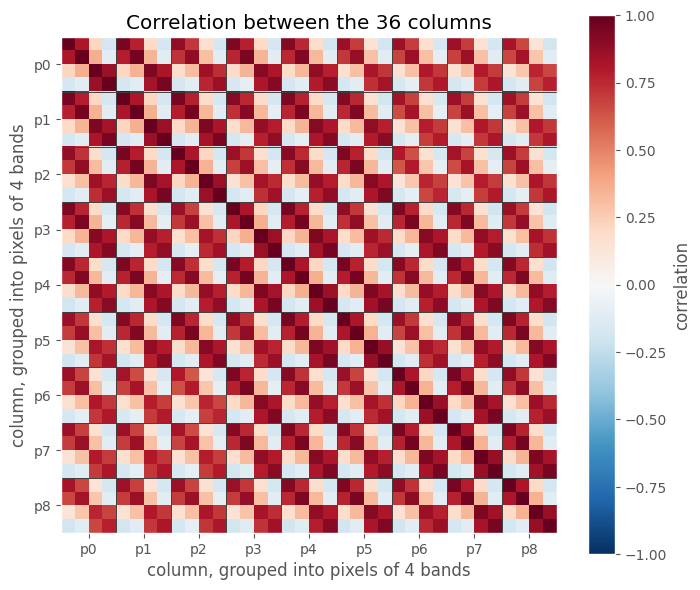

In [5]:
plt.figure(figsize=(8, 7))
plt.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)

for edge in range(4, 36, 4):
    plt.axhline(edge - 0.5, color='0.25', linewidth=0.7)
    plt.axvline(edge - 0.5, color='0.25', linewidth=0.7)

plt.xticks(np.arange(1.5, 36, 4), [f'p{p}' for p in range(9)])
plt.yticks(np.arange(1.5, 36, 4), [f'p{p}' for p in range(9)])
plt.xlabel('column, grouped into pixels of 4 bands')
plt.ylabel('column, grouped into pixels of 4 bands')
plt.title('Correlation between the 36 columns')
plt.colorbar(label='correlation')
plt.grid(False)
plt.show()

## Building the volumes

With the layout settled the reshape is one line. The values are divided by 255 to bring them into
0-1, then each of the $3 \times 3 \times 4 = 36$ positions is centred and scaled by the training
mean and standard deviation at that position, so no test statistic leaks into training.

The split is 2,000 rows to test and the remaining 4,435 to train, drawn at random with a fixed
seed. A random split is safe here: the dataset documentation states the rows were shuffled and
some were removed, so consecutive rows are not consecutive image locations and there is no
adjacency for a random split to leak across.

In [6]:
volumes = (raw / 255.0).reshape(-1, 3, 3, 4)

shuffled = np.random.default_rng(0).permutation(len(volumes))
test_rows, train_rows = shuffled[:2000], shuffled[2000:]

X_train, y_train = volumes[train_rows], labels[train_rows]
X_test, y_test = volumes[test_rows], labels[test_rows]

position_mean = X_train.mean(axis=0)
position_spread = X_train.std(axis=0) + 1e-8

X_train = (X_train - position_mean) / position_spread
X_test = (X_test - position_mean) / position_spread

baseline = np.bincount(y_test).max() / len(y_test)

print('train:', X_train.shape, np.bincount(y_train))
print('test :', X_test.shape, np.bincount(y_test))
print('one volume:', X_train[0].shape, '= (row, column, band)')
print(f'majority class baseline on the test set: {baseline:.4f}')

train: (4435, 3, 3, 4) [1049  484  954  428  500 1020]
test : (2000, 3, 3, 4) [484 219 404 198 207 488]
one volume: (3, 3, 4) = (row, column, band)
majority class baseline on the test set: 0.2440


The grid below draws one volume from each of the six classes. A volume cannot be shown as a single
picture, so each is drawn as its four band slices side by side: each slice is the $3\times3$
neighbourhood as seen in one band, and the four slices stacked along the third axis are the volume.
The scale is shared within a row so the bands of one sample can be compared against each other.

The visible pattern is that the four slices of a sample differ from each other far more than the
nine cells inside any one slice differ. That is the shape of the problem: most of the signal is
spectral, and the spatial axes carry a smaller amount on top.

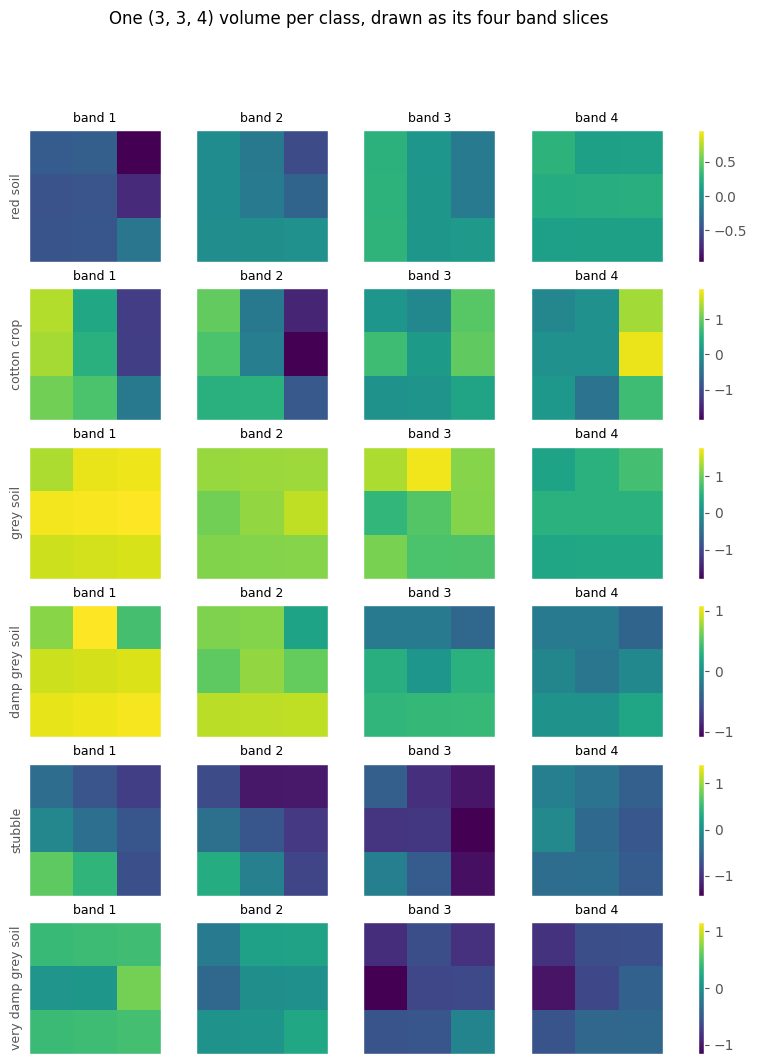

In [7]:
picked = [np.where(y_train == k)[0][3] for k in range(6)]

fig, ax = plt.subplots(6, 4, figsize=(9, 12))

for r, sample in enumerate(picked):
    cube = X_train[sample]
    limit = np.abs(cube).max()
    for b in range(4):
        a = ax[r, b]
        drawn = a.imshow(cube[:, :, b], cmap='viridis', vmin=-limit, vmax=limit)
        a.set_title(f'band {b + 1}', fontsize=9)
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
    ax[r, 0].set_ylabel(class_names[r], fontsize=9)
    fig.colorbar(drawn, ax=ax[r, :].tolist(), fraction=0.03)

plt.suptitle('One (3, 3, 4) volume per class, drawn as its four band slices')
plt.show()

## What separates the classes

The figure below averages the centre pixel over every training sample of a class and plots the
four band values against band index - the mean spectral signature of that class. The bands are, in
order, green, red, and two near-infra-red.

The signatures explain the whole problem. Cotton crop is unmistakable: living vegetation absorbs
red light and reflects infra-red strongly, so its curve rises steeply from band 2 to band 3 while
every soil curve stays flat or falls. Red soil sits high in the visible bands. The three grey soil
classes - grey, damp grey, very damp grey - are the same material at three moisture levels, and
water absorbs across the whole range, so their three curves have the same shape and differ mainly
by a vertical shift. Curves that differ only by a shift are the hard case, and they are where the
errors will turn out to be.

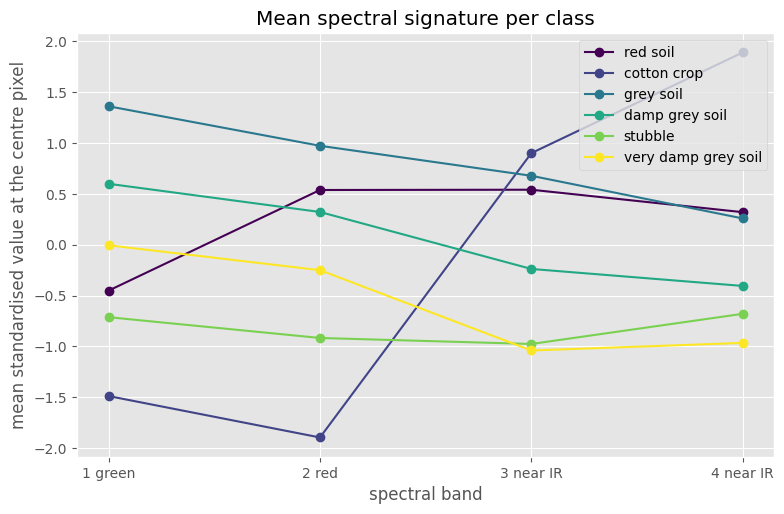

In [8]:
centre = X_train[:, 1, 1, :]
bands = np.arange(1, 5)

plt.figure(figsize=(9, 5.5))

for k in range(6):
    signature = centre[y_train == k].mean(axis=0)
    plt.plot(bands, signature, marker='o',
             color=plt.cm.viridis(k / 5), label=class_names[k])

plt.xticks(bands, ['1 green', '2 red', '3 near IR', '4 near IR'])
plt.xlabel('spectral band')
plt.ylabel('mean standardised value at the centre pixel')
plt.title('Mean spectral signature per class')
plt.legend()
plt.show()

## The 3D convolution

A filter is a $2\times2\times2$ cube of weights $K_f$ plus a bias $\beta_f$. Placed at position
$(d, i, j)$ in the volume $V$ it multiplies each of its 8 weights by the value underneath and adds
them up:

$$O[d,i,j,f] = \sum_{a=0}^{1}\sum_{b=0}^{1}\sum_{c=0}^{1} K_f[a,b,c]\; V[d+a,\; i+b,\; j+c] + \beta_f$$

A $k \times k \times k$ filter fits into a $D \times H \times W$ volume in

$$(D-k+1) \times (H-k+1) \times (W-k+1)$$

positions, so on a $(3, 3, 4)$ volume a $2\times2\times2$ filter gives a $(2, 2, 3)$ grid of
responses - 12 positions. With 16 filters the output is $(2, 2, 3, 16)$.

The reason to do it this way is the weight count. One filter is **8 weights** and that number does
not depend on the size of the volume at all - the same 8 weights would slide across a
$(3,3,4)$ cube or a $(200,200,224)$ hyperspectral scene. Here they are reused at all 12 positions,
so a pattern is recognised wherever in the volume it sits. A dense layer reading the same volume
needs one weight per voxel, $3 \times 3 \times 4 = $ **36 weights**, for a single unit, and each of
those weights only ever sees one fixed location.

`conv3d_forward` loops over the 12 output positions. It does not loop over volumes or over filters:
at each position it pulls the $2\times2\times2$ patch out of every volume in the batch, flattens
each to 8 numbers, and multiplies that $(n, 8)$ block against the $(8, f)$ matrix of flattened
filters in one matrix product.

In [9]:
def conv3d_forward(V, kernels, bias):
    n = len(V)
    f, kd, kh, kw = kernels.shape
    out_d = V.shape[1] - kd + 1
    out_h = V.shape[2] - kh + 1
    out_w = V.shape[3] - kw + 1

    out = np.zeros((n, out_d, out_h, out_w, f))
    flat_kernels = kernels.reshape(f, kd * kh * kw)

    for d in range(out_d):
        for i in range(out_h):
            for j in range(out_w):
                # the 2x2x2 patch under the filter, taken from every volume at once
                patch = V[:, d:d + kd, i:i + kh, j:j + kw].reshape(n, -1)
                out[:, d, i, j, :] = patch @ flat_kernels.T + bias

    return out


print('one filter:', 2 * 2 * 2, 'weights, reused at', 2 * 2 * 3, 'positions')
print('a dense unit on the same volume:', 3 * 3 * 4, 'weights, each used once')

one filter: 8 weights, reused at 12 positions
a dense unit on the same volume: 36 weights, each used once


## ReLU, softmax, and why there is no pooling

The convolution is linear, so stacking it with anything else linear would collapse back to one
linear map. **ReLU** breaks that:

$$\mathrm{ReLU}(x) = \max(0, x), \qquad
\frac{d}{dx}\mathrm{ReLU}(x) = \begin{cases} 1 & x > 0 \\ 0 & x \le 0 \end{cases}$$

A max pooling layer would normally follow. It is left out here, and the reason is arithmetic: the
response grid is $(2, 2, 3)$, so a $2\times2\times2$ pool has room for exactly one block per filter
and would return a single number, throwing away eleven of the twelve responses and leaving nothing
with any spatial extent for a later layer to work on. Pooling exists to make a large response map
smaller and shift-tolerant; on a grid of 12 positions there is nothing to shrink. Forcing it in
would be a layer that only destroys information, so the flatten follows ReLU directly.

Flattening the $(2, 2, 3, 16)$ result gives 192 numbers, and a dense layer turns those into 6
scores. **Softmax** turns the scores into probabilities and **cross-entropy** scores them against
the true label:

$$p_k = \frac{e^{z_k}}{\sum_m e^{z_m}}, \qquad J = -\sum_k y_k \log p_k$$

Written separately their derivatives are awkward; taken together they collapse to

$$\frac{\partial J}{\partial z} = p - y$$

which is the single line the whole backward pass starts from.

In [10]:
def softmax(scores):
    # subtract the largest score first so exp does not overflow
    e = np.exp(scores - scores.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

## Going backwards

Let $\delta = \partial J / \partial O$ be the gradient arriving at the convolution output. The
output at $(d,i,j,f)$ was the patch dotted with filter $f$, so the derivative with respect to a
filter weight is whatever that weight was multiplied by - the value in the patch - summed over
every position the filter visited:

$$\frac{\partial J}{\partial K_f[a,b,c]} = \sum_{d,i,j} \delta[d,i,j,f]\; V[d+a,\, i+b,\, j+c],
\qquad \frac{\partial J}{\partial \beta_f} = \sum_{d,i,j} \delta[d,i,j,f]$$

`conv3d_backward` walks the same 12 positions as the forward pass and accumulates that sum, again
handling the whole batch and all filters with one matrix product per position. Because a filter
weight is used at every position, its gradient is a sum over all of them - that summation is the
backward-pass counterpart of weight sharing.

In [11]:
def conv3d_backward(V, kernels, dout):
    n = len(V)
    f, kd, kh, kw = kernels.shape
    out_d, out_h, out_w = dout.shape[1], dout.shape[2], dout.shape[3]

    dkernels = np.zeros((f, kd * kh * kw))
    dbias = np.zeros(f)

    for d in range(out_d):
        for i in range(out_h):
            for j in range(out_w):
                patch = V[:, d:d + kd, i:i + kh, j:j + kw].reshape(n, -1)
                arriving = dout[:, d, i, j, :]
                dkernels += arriving.T @ patch
                dbias += arriving.sum(axis=0)

    return dkernels.reshape(f, kd, kh, kw), dbias

## The network

`__init__` builds the filters and the dense weights. Both are drawn from a normal distribution
scaled by $\sqrt{2/\text{inputs}}$ - 8 inputs for a filter, 192 for a dense unit - which keeps the
size of the signal roughly constant as it passes through ReLU. `kernel_shape` is a parameter so
that the same class can later be run on a smaller volume for the ablation at the end.

`forward` runs convolution, ReLU, flatten and the dense layer, keeping every intermediate result on
the object because the backward pass needs them.

`gradients` produces the four derivatives without touching the weights, starting from `probs` minus
the one-hot label and walking back through the dense layer, the ReLU mask and the convolution.
`backward` calls it and subtracts a multiple of each from the weights. Keeping the two apart is
what lets the gradient check below use the same code the training loop uses.

In [12]:
class CNN_3D:
    def __init__(self, volume_shape=(3, 3, 4), kernel_shape=(2, 2, 2),
                 num_filters=16, learning_rate=0.1, seed=0):
        r = np.random.default_rng(seed)

        fan_in = kernel_shape[0] * kernel_shape[1] * kernel_shape[2]
        self.kernels = r.normal(0, np.sqrt(2 / fan_in), (num_filters,) + kernel_shape)
        self.kernel_bias = np.zeros(num_filters)

        out_shape = tuple(v - k + 1 for v, k in zip(volume_shape, kernel_shape))
        flat_size = out_shape[0] * out_shape[1] * out_shape[2] * num_filters

        self.weights = r.normal(0, np.sqrt(2 / flat_size), (flat_size, 6))
        self.bias = np.zeros(6)

        self.out_shape = out_shape
        self.flat_size = flat_size
        self.learning_rate = learning_rate

    def forward(self, V):
        self.V = V
        self.conv = conv3d_forward(V, self.kernels, self.kernel_bias)
        self.relu = np.maximum(0, self.conv)
        self.flat = self.relu.reshape(len(V), -1)
        self.scores = self.flat @ self.weights + self.bias
        return softmax(self.scores)

    def gradients(self, probs, y):
        n = len(y)

        # derivative of softmax and cross-entropy together
        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1
        dscores /= n

        dweights = self.flat.T @ dscores
        dbias = dscores.sum(axis=0)

        drelu = (dscores @ self.weights.T).reshape(self.relu.shape)
        dconv = drelu * (self.conv > 0)
        dkernels, dkernel_bias = conv3d_backward(self.V, self.kernels, dconv)

        return dkernels, dkernel_bias, dweights, dbias

    def backward(self, probs, y):
        dkernels, dkernel_bias, dweights, dbias = self.gradients(probs, y)

        self.kernels -= self.learning_rate * dkernels
        self.kernel_bias -= self.learning_rate * dkernel_bias
        self.weights -= self.learning_rate * dweights
        self.bias -= self.learning_rate * dbias

    def predict(self, V):
        return self.forward(V).argmax(axis=1)


net = CNN_3D()
print('convolution output:', net.out_shape, 'per filter, flattened to', net.flat_size)
print('filter weights:', net.kernels.size, '+', net.kernel_bias.size, 'biases')
print('dense weights :', net.weights.size, '+', net.bias.size, 'biases')
print('total parameters:', net.kernels.size + net.kernel_bias.size + net.weights.size + net.bias.size)

convolution output: (2, 2, 3) per filter, flattened to 192
filter weights: 128 + 16 biases
dense weights : 1152 + 6 biases
total parameters: 1302


## Checking the derivatives

A wrong derivative does not raise an error. The network simply trains badly, and there is nothing
to look at that says why. So the analytic gradients are compared against the loss itself.

Move one weight up by $\varepsilon = 10^{-5}$, move it down by the same amount, and measure

$$\frac{J(w + \varepsilon) - J(w - \varepsilon)}{2\varepsilon}$$

which approaches $\partial J / \partial w$ as $\varepsilon$ shrinks. If `gradients` is right the
two numbers match. The cell picks the five filter weights and five dense weights with the largest
gradients, since a weight whose gradient is near zero would pass the check no matter what.

In [13]:
def loss_of(model, V, y):
    probs = model.forward(V)
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()


check_net = CNN_3D(num_filters=4, learning_rate=0.0, seed=1)
V_batch, y_batch = X_train[:16], y_train[:16]

dkernels, _, dweights, _ = check_net.gradients(check_net.forward(V_batch), y_batch)

eps = 1e-5


def measured_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = loss_of(check_net, V_batch, y_batch)
    param[index] = original - eps
    down = loss_of(check_net, V_batch, y_batch)
    param[index] = original
    return (up - down) / (2 * eps)


def largest(grad, how_many=5):
    flat = np.argsort(-np.abs(grad).ravel())[:how_many]
    return [tuple(int(v) for v in idx) for idx in zip(*np.unravel_index(flat, grad.shape))]


worst = 0.0
print(f'{"weight":24s} {"from gradients":>16s} {"measured":>16s}')
for index in largest(dkernels):
    analytic, measured = dkernels[index], measured_slope(check_net.kernels, index)
    worst = max(worst, abs(analytic - measured))
    print(f'kernel {str(index):17s} {analytic:16.8f} {measured:16.8f}')
for index in largest(dweights):
    analytic, measured = dweights[index], measured_slope(check_net.weights, index)
    worst = max(worst, abs(analytic - measured))
    print(f'dense  {str(index):17s} {analytic:16.8f} {measured:16.8f}')

print()
print(f'largest disagreement: {worst:.3e}')

weight                     from gradients         measured
kernel (0, 1, 0, 0)            0.68446471       0.68446471
kernel (0, 0, 0, 0)            0.64028631       0.64028631
kernel (3, 0, 0, 1)           -0.61175958      -0.61175958
kernel (0, 1, 1, 0)            0.59774919       0.59774919
kernel (0, 0, 0, 1)            0.59767186       0.59767186
dense  (15, 2)                 0.66263095       0.66263095
dense  (39, 2)                 0.61917767       0.61917767
dense  (27, 2)                 0.56632172       0.56632172
dense  (3, 2)                  0.54839133       0.54839133
dense  (39, 1)                -0.46248637      -0.46248637

largest disagreement: 1.317e-10


The two columns agree to eight decimal places on gradients of size 0.4 to 0.7, so `conv3d_backward`
computes what the loss actually does.

## Training

Sixty passes over the training set. Each pass reshuffles the rows and works through them in batches
of 32, running `forward` then `backward` on each. Loss and accuracy on both halves are recorded
after every pass.

In [14]:
def loss_and_accuracy(net, V, y):
    probs = net.forward(V)
    loss = -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()
    return loss, (probs.argmax(axis=1) == y).mean()


started = time.time()
net = CNN_3D(volume_shape=(3, 3, 4), kernel_shape=(2, 2, 2),
             num_filters=16, learning_rate=0.1, seed=0)

train_loss, test_loss, train_acc, test_acc = [], [], [], []
batch_size = 32

for epoch in range(60):
    order = np.random.default_rng(epoch).permutation(len(X_train))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        probs = net.forward(X_train[batch])
        net.backward(probs, y_train[batch])

    tl, ta = loss_and_accuracy(net, X_train, y_train)
    vl, va = loss_and_accuracy(net, X_test, y_test)
    train_loss.append(tl); train_acc.append(ta)
    test_loss.append(vl); test_acc.append(va)

    if (epoch + 1) % 10 == 0:
        print(f'epoch {epoch+1:2d}  train loss {tl:.4f} acc {ta:.4f}  |  test loss {vl:.4f} acc {va:.4f}')

print()
print(f'training took {time.time() - started:.1f} seconds')
print(f'final test accuracy    : {test_acc[-1]:.4f}')
print(f'majority class baseline: {baseline:.4f}')

epoch 10  train loss 0.2679 acc 0.8983  |  test loss 0.2957 acc 0.8900


epoch 20  train loss 0.2318 acc 0.9134  |  test loss 0.2751 acc 0.8980


epoch 30  train loss 0.2160 acc 0.9224  |  test loss 0.2674 acc 0.9040


epoch 40  train loss 0.2079 acc 0.9276  |  test loss 0.2634 acc 0.9090


epoch 50  train loss 0.1940 acc 0.9269  |  test loss 0.2503 acc 0.9050


epoch 60  train loss 0.1883 acc 0.9290  |  test loss 0.2486 acc 0.9045

training took 9.6 seconds
final test accuracy    : 0.9045
majority class baseline: 0.2440


## The training curves

Loss on the left, accuracy on the right, training and test on the same axes.

Both losses drop quickly for the first ten passes and then flatten. The gap between the two curves
stays small - a point or two of accuracy - so the model is not memorising the training set. With
1,302 parameters against 4,435 training rows that is what should happen, and it means the ceiling
here is the model and the data rather than a shortage of examples.

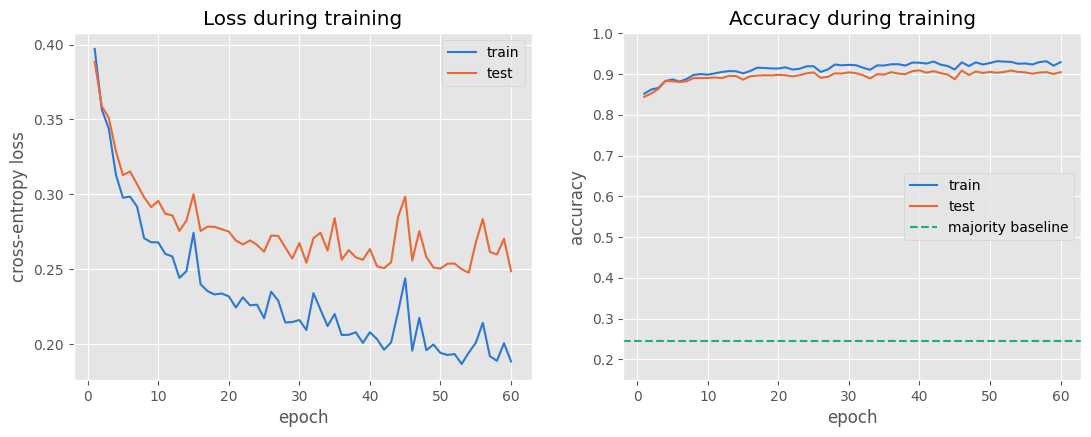

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(train_loss) + 1)

ax[0].plot(epochs, train_loss, color=blue, label='train')
ax[0].plot(epochs, test_loss, color=orange, label='test')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('cross-entropy loss')
ax[0].set_title('Loss during training')
ax[0].legend()

ax[1].plot(epochs, train_acc, color=blue, label='train')
ax[1].plot(epochs, test_acc, color=orange, label='test')
ax[1].axhline(baseline, color=green, linestyle='--', label='majority baseline')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.15, 1.0)
ax[1].set_title('Accuracy during training')
ax[1].legend()

plt.show()

## The filters it learned

Each filter is a $2\times2\times2$ cube, which cannot be drawn as one picture. It is drawn instead
as its two depth slices side by side. The depth axis of the volume is the image row, so slice 0
holds the weights applied to the upper of the two image rows and slice 1 to the lower one. Inside
each slice the horizontal axis is the image column and the vertical axis is the spectral band, so
one slice is a $2 \times 2$ block of (band, column) weights.

Dark squares are positive weights and light ones negative. A filter fires hardest on a patch of the
volume that looks like it. A filter whose two slices are near-copies is one that ignores which
image row it is on and responds purely to the band pattern; a filter whose slices differ is one
that is sensitive to a change across the two rows, which is the part of its response that a purely
spectral model could not produce.

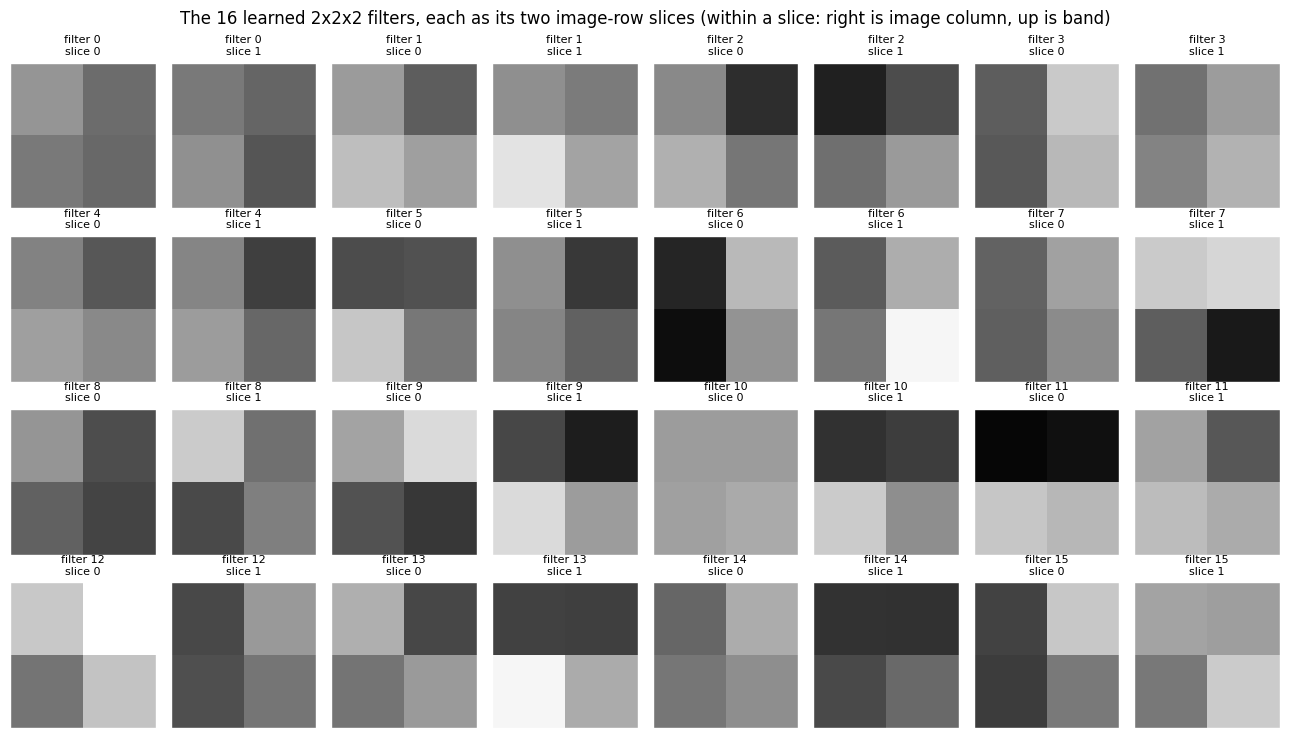

slice difference per filter (mean absolute):
[0.251 0.272 0.773 0.372 0.21  0.591 0.882 0.878 0.569 1.692 0.89  0.81
 1.133 0.865 0.83  0.908]


In [16]:
fig, ax = plt.subplots(4, 8, figsize=(13, 7.5))

limit = np.abs(net.kernels).max()
for f in range(len(net.kernels)):
    for d in range(2):
        a = ax[f // 4, (f % 4) * 2 + d]
        a.imshow(net.kernels[f, d].T, cmap='gray_r', origin='lower',
                 vmin=-limit, vmax=limit)
        a.set_title(f'filter {f}\nslice {d}', fontsize=8)
        a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The 16 learned 2x2x2 filters, each as its two image-row slices '
             '(within a slice: right is image column, up is band)')
plt.tight_layout()
plt.show()

print('slice difference per filter (mean absolute):')
print(np.round(np.abs(net.kernels[:, 0] - net.kernels[:, 1]).mean(axis=(1, 2)), 3))

## One volume through the network

The filters above are the weights. What they do to an actual sample is a separate thing, and it is
worth following one volume through every stage in order. The cell below takes one test volume - a
cotton crop sample - runs it through the trained network, and keeps the intermediate arrays that
`forward` leaves on the object: `conv` before the activation, `relu` after it, `flat`, and `scores`.

The shapes printed are the whole story of the forward pass:

$$(3, 3, 4) \;\xrightarrow{\;2\times2\times2\;}\; (2, 2, 3, 16) \;\xrightarrow{\;\mathrm{ReLU}\;}\;
(2, 2, 3, 16) \;\xrightarrow{\;\text{flatten}\;}\; 192 \;\xrightarrow{\;\text{dense}\;}\; 6$$

The volume shrinks because there is no padding. A filter has to sit entirely inside the volume, so
along an axis of length $D$ a filter of length $k$ has $D - k + 1$ places to start, and that rule
applies to all three axes at once:

$$(3, 3, 4) \longrightarrow (3-2+1,\; 3-2+1,\; 4-2+1) = (2, 2, 3)$$

Three rows become two row pairs, three columns become two column pairs, four bands become three
band pairs. Every output value is one filter's reading of one such pair-of-rows by pair-of-columns
by pair-of-bands block, so the axes of the output are still spatial and spectral - just one step
coarser and one shorter on each axis.

In [17]:
walk = int(np.where(y_test == 1)[0][0])
cube = X_test[walk]

walk_probs = net.forward(X_test[walk:walk + 1])[0]
walk_conv = net.conv[0]
walk_relu = net.relu[0]
walk_flat = net.flat[0]
walk_scores = net.scores[0]

print('input volume      :', cube.shape, '= (row, column, band)')
print('after convolution :', walk_conv.shape, '= (row pair, column pair, band pair, filter)')
print('after ReLU        :', walk_relu.shape, end='  ')
print(f'- {int((walk_relu == 0).sum())} of {walk_relu.size} values clipped to zero')
print('flattened         :', walk_flat.shape)
print('dense output      :', walk_scores.shape)
print()
print('true class     :', class_names[y_test[walk]])
print('predicted class:', class_names[int(walk_probs.argmax())],
      f'with probability {walk_probs.max():.4f}')

input volume      : (3, 3, 4) = (row, column, band)
after convolution : (2, 2, 3, 16) = (row pair, column pair, band pair, filter)
after ReLU        : (2, 2, 3, 16)  - 84 of 192 values clipped to zero
flattened         : (192,)
dense output      : (6,)

true class     : cotton crop
predicted class: cotton crop with probability 1.0000


**Stage 1 - the input.** The volume drawn as its four band slices. Each slice is the $3\times3$
neighbourhood in one band, on a diverging scale centred at zero because the values are standardised,
so red is above the training mean at that position and blue is below it. The rise from the two
visible bands to the two infra-red bands is the vegetation signature that makes this class easy.

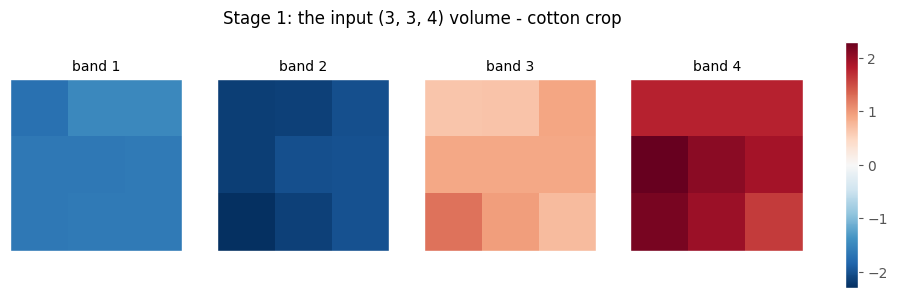

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(11, 3.2))

limit = np.abs(cube).max()
for b in range(4):
    drawn = ax[b].imshow(cube[:, :, b], cmap='RdBu_r', vmin=-limit, vmax=limit)
    ax[b].set_title(f'band {b + 1}', fontsize=10)
    ax[b].set_xticks([]); ax[b].set_yticks([]); ax[b].grid(False)

fig.colorbar(drawn, ax=ax.tolist(), fraction=0.02)
plt.suptitle(f'Stage 1: the input (3, 3, 4) volume - {class_names[y_test[walk]]}')
plt.show()

**Stages 2 and 3 - the convolution and the ReLU.** Six filters are shown, the six whose response to
this volume is largest in absolute value. Each filter turns the volume into a $(2, 2, 3)$ block, and
each block is drawn as its three band-pair slices; within a slice the two rows are the two image-row
pairs and the two columns are the two image-column pairs.

The left three columns are the raw convolution output, before any activation, on a diverging scale
so negative responses are visible as blue. The right three are the same values after
$\mathrm{ReLU}(x) = \max(0, x)$, on the same scale. Every square that is blue on the left is white
on the right: those are the values the ReLU set to zero, and they are the ones that will send no
gradient back on the next update because the ReLU derivative is zero there.

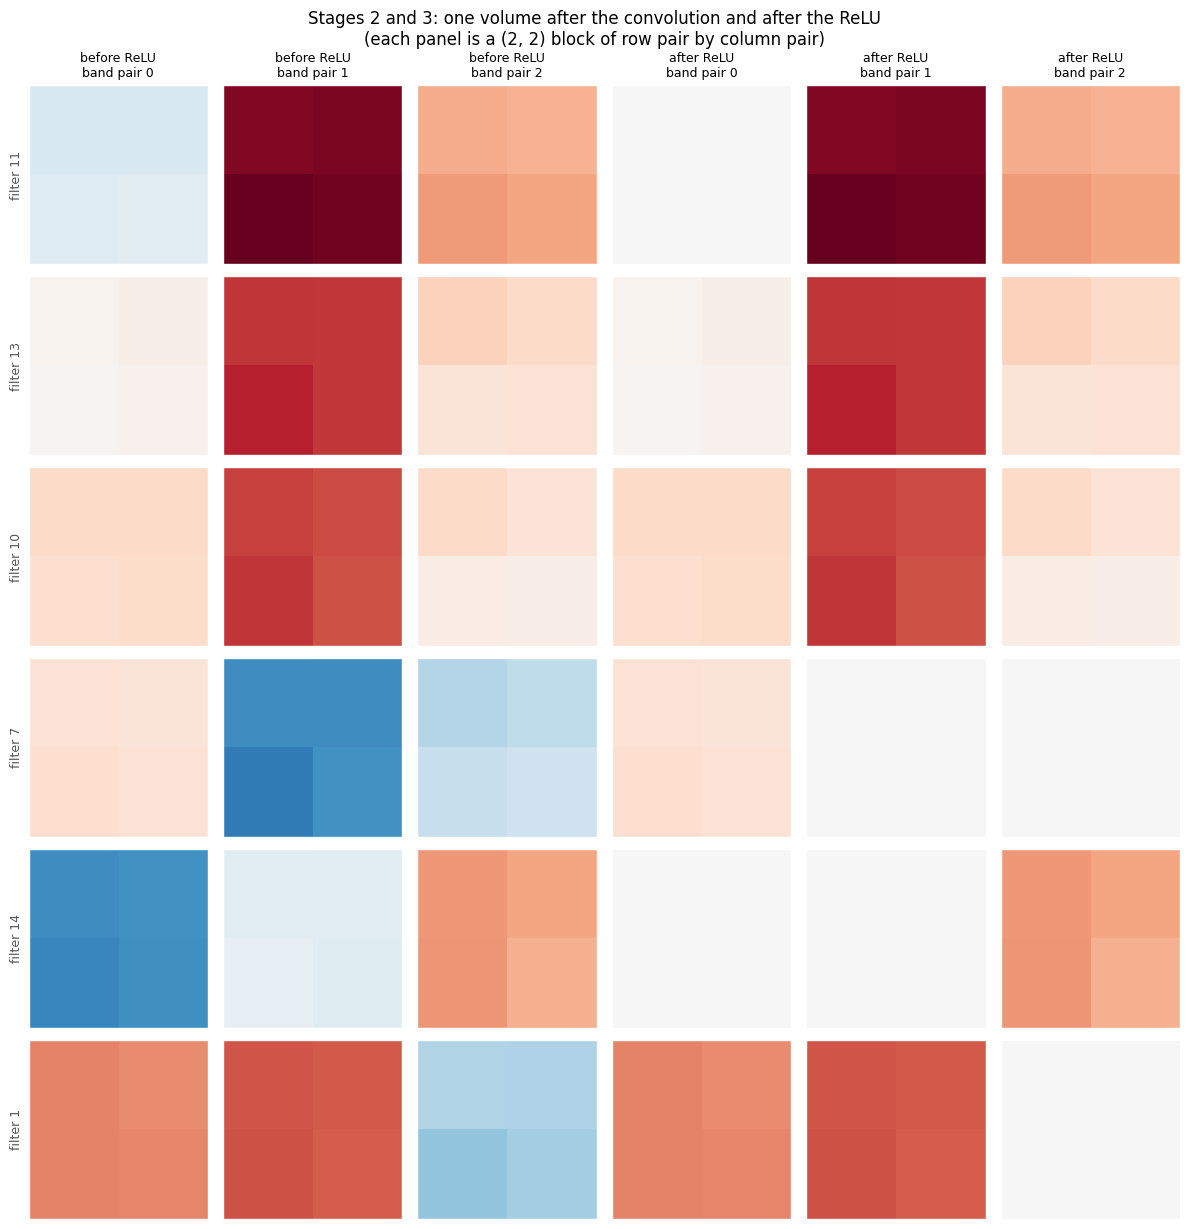

of the 192 responses, 84 were at or below zero and were clipped


In [19]:
strongest = np.argsort(-np.abs(walk_conv).max(axis=(0, 1, 2)))[:6]

fig, ax = plt.subplots(6, 6, figsize=(12, 12.5))

limit = np.abs(walk_conv[:, :, :, strongest]).max()
for r, f in enumerate(strongest):
    for c in range(3):
        left, right = ax[r, c], ax[r, c + 3]
        left.imshow(walk_conv[:, :, c, f], cmap='RdBu_r', vmin=-limit, vmax=limit)
        right.imshow(walk_relu[:, :, c, f], cmap='RdBu_r', vmin=-limit, vmax=limit)
        for a in (left, right):
            a.set_xticks([]); a.set_yticks([]); a.grid(False)
        if r == 0:
            left.set_title(f'before ReLU\nband pair {c}', fontsize=9)
            right.set_title(f'after ReLU\nband pair {c}', fontsize=9)
    ax[r, 0].set_ylabel(f'filter {f}', fontsize=9)

plt.suptitle('Stages 2 and 3: one volume after the convolution and after the ReLU\n'
             '(each panel is a (2, 2) block of row pair by column pair)')
plt.tight_layout()
plt.show()

print(f'of the {walk_relu.size} responses, {int((walk_conv <= 0).sum())} were at or below zero '
      f'and were clipped')

**Stages 4 and 5 - the flatten, the scores and the probabilities.** Flattening is a reshape and
nothing else: the $(2, 2, 3, 16)$ block is laid out as 192 numbers in row-major order, so the
strip below runs through row pair, then column pair, then band pair, then filter, with filter
varying fastest. The 84 dark bands in it are the entries the ReLU set to zero.

The dense layer takes those 192 numbers to 6 scores, and softmax turns the scores into
probabilities:

$$z = W^\top h + b, \qquad p_k = \frac{e^{z_k}}{\sum_m e^{z_m}}$$

Softmax is monotone, so the largest score is always the largest probability - what it changes is the
spacing. Exponentiating turns a gap into a ratio: the winning score here is about 14 above the
runner-up, and $e^{14}$ is over a million, so the probability comes out indistinguishable from 1
even though the score itself is nothing extreme.

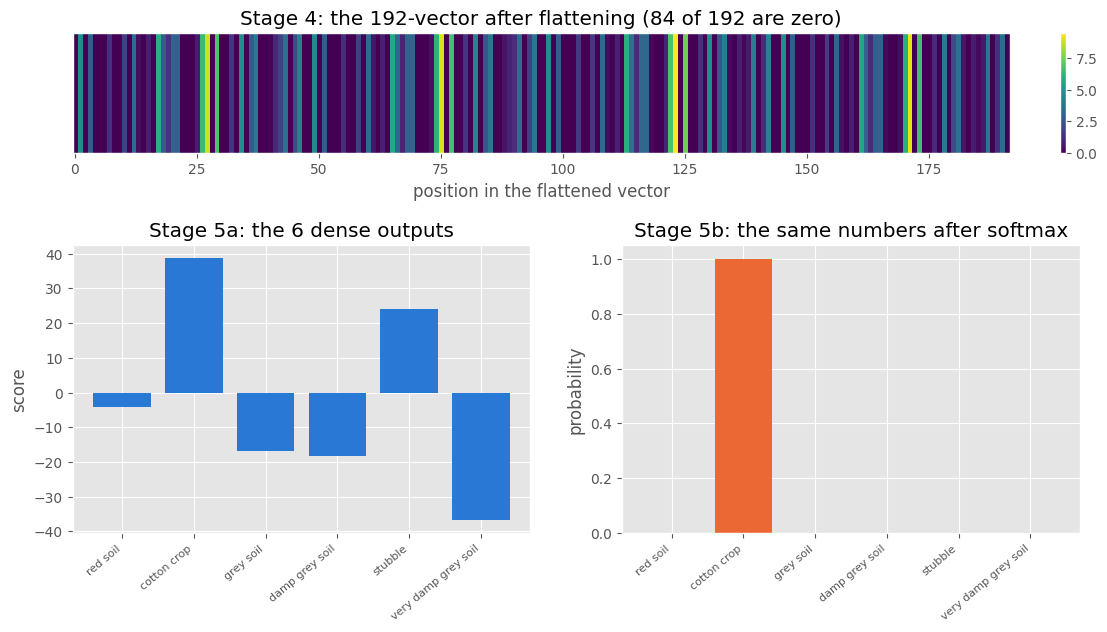

class                       score   probability
red soil                  -4.1014      0.000000
cotton crop               38.7471      1.000000
grey soil                -16.7052      0.000000
damp grey soil           -18.2285      0.000000
stubble                   24.2118      0.000000
very damp grey soil      -36.7966      0.000000


In [20]:
fig = plt.figure(figsize=(13, 6.5))
panels = fig.add_gridspec(2, 2, height_ratios=[1, 2.4], hspace=0.45)

strip = fig.add_subplot(panels[0, :])
drawn = strip.imshow(walk_flat[None, :], cmap='viridis', aspect='auto')
strip.set_yticks([])
strip.set_xlabel('position in the flattened vector')
strip.set_title(f'Stage 4: the 192-vector after flattening '
                f'({int((walk_flat == 0).sum())} of 192 are zero)')
strip.grid(False)
fig.colorbar(drawn, ax=strip, fraction=0.02)

left = fig.add_subplot(panels[1, 0])
left.bar(range(6), walk_scores, color=blue)
left.set_xticks(range(6))
left.set_xticklabels(class_names, rotation=40, ha='right', fontsize=8)
left.set_ylabel('score')
left.set_title('Stage 5a: the 6 dense outputs')

right = fig.add_subplot(panels[1, 1])
right.bar(range(6), walk_probs, color=orange)
right.set_xticks(range(6))
right.set_xticklabels(class_names, rotation=40, ha='right', fontsize=8)
right.set_ylabel('probability')
right.set_ylim(0, 1.05)
right.set_title('Stage 5b: the same numbers after softmax')

plt.show()

print(f'{"class":22s} {"score":>10s} {"probability":>13s}')
for k in range(6):
    print(f'{class_names[k]:22s} {walk_scores[k]:10.4f} {walk_probs[k]:13.6f}')

## Where the mistakes are

The table counts every test row by what it was against what the network said. The diagonal is the
correct answers, and the row percentages underneath say how each class fared on its own terms.

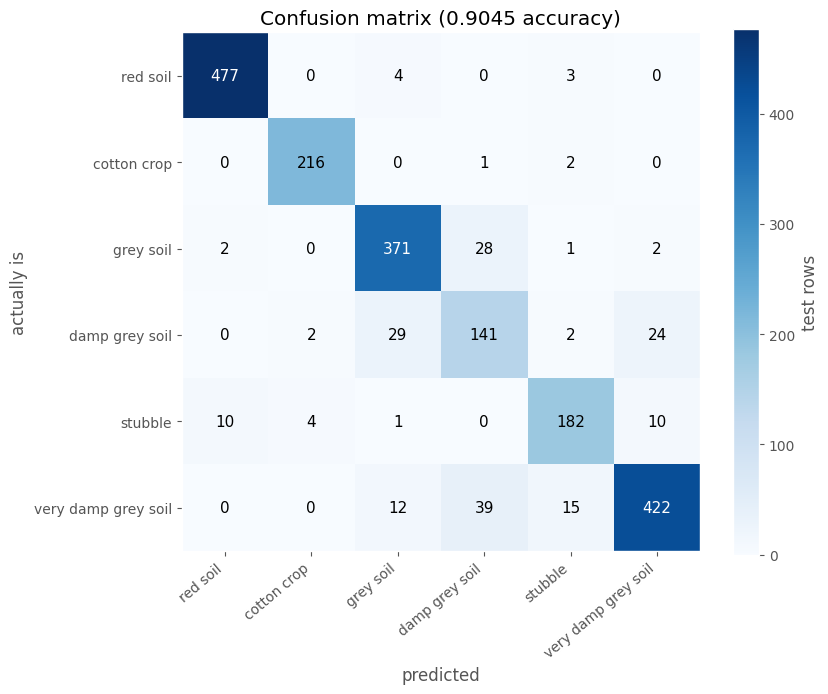

red soil              :  477 of  484 correct (0.986)
cotton crop           :  216 of  219 correct (0.986)
grey soil             :  371 of  404 correct (0.918)
damp grey soil        :  141 of  198 correct (0.712)
stubble               :  182 of  207 correct (0.879)
very damp grey soil   :  422 of  488 correct (0.865)


In [21]:
predictions = net.predict(X_test)

table = np.zeros((6, 6), dtype=int)
for true, guess in zip(y_test, predictions):
    table[true, guess] += 1

plt.figure(figsize=(8.5, 7))
plt.imshow(table, cmap='Blues')
for i in range(6):
    for j in range(6):
        plt.text(j, i, table[i, j], ha='center', va='center', fontsize=11,
                 color='white' if table[i, j] > table.max() / 2 else 'black')
plt.xticks(range(6), class_names, rotation=40, ha='right')
plt.yticks(range(6), class_names)
plt.xlabel('predicted'); plt.ylabel('actually is')
plt.title(f'Confusion matrix ({(predictions == y_test).mean():.4f} accuracy)')
plt.colorbar(label='test rows')
plt.grid(False)
plt.tight_layout()
plt.show()

for i in range(6):
    print(f'{class_names[i]:22s}: {table[i, i]:4d} of {table[i].sum():4d} correct '
          f'({table[i, i] / table[i].sum():.3f})')

The errors are concentrated in one place. Red soil and cotton crop are almost never missed - both
above 0.98 - because their spectral signatures sit well away from everything else. Everything that
goes wrong involves the three grey soil classes.

Damp grey soil is the worst at 0.712, and its 57 errors are 29 rows called grey soil and 24 called
very damp grey soil. It is the middle of a moisture sequence and it is mostly being pulled to the
class on either side of it. Very damp grey soil loses 39 rows the same way. This is the mean
spectral signature plot showing up again: three curves of the same shape separated by a vertical
offset, with the middle one having a neighbour in both directions. The class boundaries in that
region are genuinely a matter of degree rather than of kind.

## Does the neighbourhood help

Everything above assumes the $3\times3$ neighbourhood is worth having. That can be measured
directly: train the same network on the centre pixel alone, a $(1, 1, 4)$ volume containing only
columns 16-19, and compare. The convolution code is unchanged - only the kernel shrinks to
$(1, 1, 2)$, which is what fits a volume with no spatial extent, and it slides along the band axis
only. Everything else, including the number of filters, the learning rate, the seed and the number
of epochs, is held fixed.

The gap between the two accuracies is the contribution of the eight surrounding pixels, and it is
the number that says whether the third axis and the spatial axes are both pulling their weight.

centre pixel only, (1, 1, 4) volume : 0.8540
full 3x3 neighbourhood, (3, 3, 4)   : 0.9045
majority class baseline             : 0.2440

the eight surrounding pixels are worth +0.0505


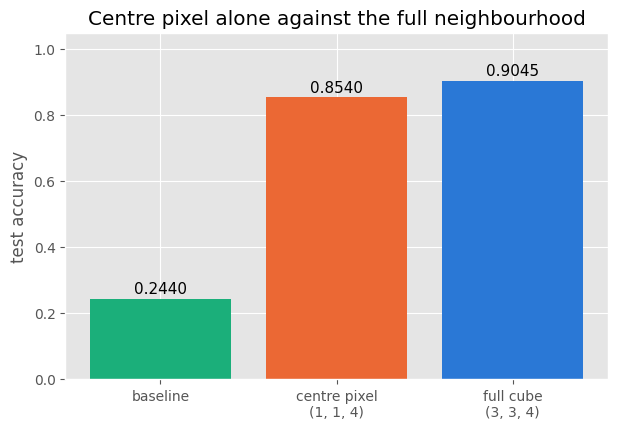

In [22]:
X_train_centre = X_train[:, 1:2, 1:2, :]
X_test_centre = X_test[:, 1:2, 1:2, :]

centre_net = CNN_3D(volume_shape=(1, 1, 4), kernel_shape=(1, 1, 2),
                    num_filters=16, learning_rate=0.1, seed=0)

for epoch in range(60):
    order = np.random.default_rng(epoch).permutation(len(X_train_centre))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        probs = centre_net.forward(X_train_centre[batch])
        centre_net.backward(probs, y_train[batch])

_, centre_acc = loss_and_accuracy(centre_net, X_test_centre, y_test)
full_acc = test_acc[-1]

print(f'centre pixel only, (1, 1, 4) volume : {centre_acc:.4f}')
print(f'full 3x3 neighbourhood, (3, 3, 4)   : {full_acc:.4f}')
print(f'majority class baseline             : {baseline:.4f}')
print()
print(f'the eight surrounding pixels are worth {full_acc - centre_acc:+.4f}')

plt.figure(figsize=(7, 4.5))
plt.bar(['baseline', 'centre pixel\n(1, 1, 4)', 'full cube\n(3, 3, 4)'],
        [baseline, centre_acc, full_acc], color=[green, orange, blue])
for x, value in enumerate([baseline, centre_acc, full_acc]):
    plt.text(x, value + 0.015, f'{value:.4f}', ha='center', fontsize=11)
plt.ylabel('test accuracy')
plt.ylim(0, 1.05)
plt.title('Centre pixel alone against the full neighbourhood')
plt.show()

The centre pixel's four bands alone reach 0.854, so most of the answer is spectral - which is no
surprise, since the label is defined by what the centre pixel is made of. Adding the eight
neighbours takes it to 0.905. That is 5.1 points, and it is a third of the remaining error removed.

The neighbourhood helps for a physical reason. The classes here are regions of ground, not isolated
points, so a pixel surrounded by eight pixels of similar reflectance is much more likely to be in
the interior of a uniform patch than a pixel whose neighbours disagree with it. The convolution
picks that up because its filters straddle two pixels and two bands at once, and a weight pattern
that is positive on one pixel and negative on the neighbour measures exactly that local agreement.
That gain is the specific thing a 3D convolution over a spatial-spectral cube is for.

## Summary

- A 3D convolution needs data with genuine locality on three axes. Landsat rows have it as
  supplied: 36 columns reshape into a $(3, 3, 4)$ volume of image row by image column by spectral
  band, and all three axes are physical.
- The column layout was verified rather than assumed. Band varies fastest - grouping the 36x36
  correlation matrix by that ordering separates same-band pairs at 0.88 from unrelated pairs at
  0.28, while the pixel-fastest ordering does not separate at all. Correlation within a band falls
  monotonically with row-major grid distance (0.944 at distance 1 to 0.811 at the corners), and the
  per-pixel F-ratio against the label peaks at pixel 4, confirming the centre pixel is columns
  16-19.
- A $2\times2\times2$ filter is 8 weights, a count that does not depend on the size of the volume,
  reused at all 12 output positions. A dense unit reading the same volume needs 36, each tied to
  one fixed location.
- No pooling layer. A $2\times2\times2$ pool on a $(2, 2, 3)$ response grid would return one number
  per filter and discard eleven of twelve responses. There is nothing to shrink at this size, so
  adding it would only lose information.
- The backward pass mirrors the forward one: the gradient for a filter weight is the value it was
  multiplied by, summed over every position the filter visited. The finite-difference check matches
  the hand-written derivatives to eight decimal places.
- Test accuracy is 0.905 against a majority-class baseline of 0.244. The errors are almost entirely
  confined to grey soil, damp grey soil and very damp grey soil, which are one material at three
  moisture levels; damp grey soil, the middle one, is the worst class at 0.712 and loses nearly
  equal numbers to the classes on either side of it.
- The centre pixel's four bands alone give 0.854. The full neighbourhood gives 0.905, so the eight
  surrounding pixels are worth 5.1 points - a real contribution, and the direct measurement of what
  the spatial axes of the convolution are adding over a purely spectral model.

# Section 2 - genuinely volumetric data

Everything in Section 1 is a real 3D convolution, but the volume is $3\times3\times4$: a
$2\times2\times2$ filter has 12 places to sit in it and no room for a pooling layer, which is enough
to demonstrate the operation and its derivatives but not enough to show a 3D convolution doing
spatial work on a shape. UCI has no volumetric dataset at all, so this section uses **ModelNet10**,
the standard benchmark for exactly this: 4,899 CAD meshes of household objects in 10 categories,
which get turned into occupancy grids and classified.

The steps are all written here from the mesh file upwards - reading the `.OFF` files, sampling
points on the triangles, binning them into a grid - because that conversion is where the interesting
part of voxel data lies. The network then is:

```
16 x 16 x 16 occupancy grid
  -> convolution, 8 filters of 3x3x3  -> (14, 14, 14, 8)
  -> ReLU
  -> max pool 2x2x2                   -> (7, 7, 7, 8)
  -> flatten                          -> 2744
  -> dense layer                      -> 5
  -> softmax
```

`conv3d_forward` and `conv3d_backward` are reused unchanged from Section 1. The pooling layer, which
made no sense on a $(2, 2, 3)$ response grid, does make sense on a $14^3$ one and is added here.

## Getting the meshes

The archive is 473 MB and lives at `3dvision.princeton.edu`. The cell downloads it into
`./data/modelnet10/` and unzips it **only if the extracted directory is not already there**, and
prints which of the two happened. `data/` is in `.gitignore`, so nothing here is committed.

Inside the archive each category is a directory holding `train/` and `test/` subdirectories of
`.OFF` files, and that split is the official one, so it is used as given rather than re-drawn.

In [23]:
import os
import urllib.request
import zipfile

url = 'http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip'
data_dir = '../data/modelnet10'
mesh_root = os.path.join(data_dir, 'ModelNet10')
archive = os.path.join(data_dir, 'ModelNet10.zip')

if os.path.isdir(mesh_root):
    print('cached copy already present, nothing downloaded:', mesh_root)
else:
    os.makedirs(data_dir, exist_ok=True)
    print('downloading ModelNet10 (473 MB) from', url)
    urllib.request.urlretrieve(url, archive)
    print(f'downloaded {os.path.getsize(archive) / 1e6:.0f} MB, extracting')
    with zipfile.ZipFile(archive) as bundle:
        bundle.extractall(data_dir)
    os.remove(archive)
    print('extracted to', mesh_root)

categories = sorted(d for d in os.listdir(mesh_root)
                    if os.path.isdir(os.path.join(mesh_root, d, 'train')))

print()
print(f'{"category":14s} {"train":>7s} {"test":>7s}')
total_meshes = 0
for name in categories:
    n_train = len([f for f in os.listdir(os.path.join(mesh_root, name, 'train')) if f.endswith('.off')])
    n_test = len([f for f in os.listdir(os.path.join(mesh_root, name, 'test')) if f.endswith('.off')])
    total_meshes += n_train + n_test
    print(f'{name:14s} {n_train:7d} {n_test:7d}')
print()
print('meshes in total:', total_meshes)

cached copy already present, nothing downloaded: ../data/modelnet10/ModelNet10

category         train    test
bathtub            106      50
bed                515     100
chair              889     100
desk               200      86
dresser            200      86
monitor            465     100
night_stand        200      86
sofa               680     100
table              392     100
toilet             344     100

meshes in total: 4899


## Reading an OFF file

An `.OFF` file is plain text. The first line is the word `OFF`, sometimes with the three counts
stuck onto the same line with no space after it. Then comes a line of three integers, the number of
vertices, the number of faces and the number of edges - the edge count is conventionally 0 and is
ignored. Then one line per vertex holding three floating-point coordinates, then one line per face
holding a vertex count $k$ followed by $k$ vertex indices.

Faces with $k > 3$ are split into a fan around the first corner:

$$(i_1, i_2, \ldots, i_k) \;\longrightarrow\; (i_1, i_2, i_3),\, (i_1, i_3, i_4),\, \ldots,\,
(i_1, i_{k-1}, i_k)$$

which covers the polygon exactly when it is convex and planar, and both hold for the faces in these
files.

`read_off` reads the whole file, splits it on whitespace and works through the resulting token list,
so line breaks inside a record do not matter. When every face is a triangle the face block is
exactly $4 n_{\text{faces}}$ tokens and is reshaped in one step; otherwise it falls back to walking
the list face by face. Anything that does not parse - a bad header, a count that does not match the
number of tokens, a face index out of range - raises, and the caller counts the file as skipped
rather than stopping.

In [24]:
def read_off(path):
    with open(path) as handle:
        tokens = handle.read().split()

    # the header is either 'OFF' alone or 'OFF' with the counts stuck to it
    if tokens[0] == 'OFF':
        head = 1
    elif tokens[0].startswith('OFF'):
        tokens[0] = tokens[0][3:]
        head = 0
    else:
        raise ValueError('not an OFF file')

    n_verts, n_faces = int(tokens[head]), int(tokens[head + 1])
    head += 3

    verts = np.array(tokens[head:head + 3 * n_verts], dtype=float).reshape(n_verts, 3)
    rest = tokens[head + 3 * n_verts:]

    # fast path: every face is a triangle, so the block is 4 tokens per face
    if len(rest) == 4 * n_faces:
        block = np.array(rest, dtype=int).reshape(n_faces, 4)
        if (block[:, 0] == 3).all():
            return verts, block[:, 1:]

    triangles = []
    at = 0
    for _ in range(n_faces):
        k = int(rest[at])
        corners = [int(v) for v in rest[at + 1:at + 1 + k]]
        at += 1 + k
        for t in range(1, k - 1):
            # fan: first corner joined to every consecutive pair of the rest
            triangles.append((corners[0], corners[t], corners[t + 1]))

    return verts, np.array(triangles, dtype=int)


example = os.path.join(mesh_root, 'chair', 'train', 'chair_0001.off')
example_verts, example_tris = read_off(example)

print('file      :', example)
print('vertices  :', example_verts.shape)
print('triangles :', example_tris.shape)
print('coordinate ranges:', np.round(example_verts.min(axis=0), 2), 'to',
      np.round(example_verts.max(axis=0), 2))

file      : ../data/modelnet10/ModelNet10/chair/train/chair_0001.off
vertices  : (2382, 3)
triangles : (2234, 3)
coordinate ranges: [-10.2  -11.64 -18.36] to [10.2  11.64 18.36]


## Turning a mesh into voxels

A mesh is a list of triangles floating in whatever coordinate system the modeller used. Two things
have to happen before a convolution can be run over it: it has to be put in a fixed box, and it has
to be turned into an array.

**Into a unit box.** The centre of the bounding box is subtracted and everything is divided by the
largest of the three extents, which puts every model inside $[-0.5, 0.5]^3$ with its longest
dimension exactly filling it. Using the bounding-box centre rather than the mean of the vertices
matters, because the mean is pulled towards wherever the modeller happened to put dense detail.
Dividing by the largest extent rather than each extent separately keeps the proportions: a table
stays flat and a monitor stays thin, which is most of what tells these classes apart.

**Sampling the surface.** The mesh is a set of triangles, so points on it are drawn in two steps.
First pick a triangle, with probability proportional to its area, so that a large triangle receives
proportionally more points than a small one - otherwise a coarsely modelled tabletop of two huge
triangles would get the same number of points as two tiny ones on a chair leg. Areas come from the
cross product:

$$A = \tfrac{1}{2}\lVert (B - A) \times (C - A) \rVert$$

and a triangle is picked by taking the cumulative sum of the areas, drawing $u \sim U(0, A_{tot})$,
and finding where $u$ lands with a binary search.

Second, pick a point inside that triangle. The map used is

$$P = (1 - \sqrt{r_1})A + \sqrt{r_1}(1 - r_2)B + \sqrt{r_1}\, r_2\, C,
\qquad r_1, r_2 \sim U(0, 1)$$

The square root is what makes this uniform over the area. Taking $r_1$ directly instead would put
too many points near vertex $A$: the set of points with parameter below $t$ is a scaled copy of the
triangle, and area scales as the square of length, so the fraction of area within $t$ is $t^2$, not
$t$. Drawing $t = \sqrt{r_1}$ gives $P(t \le s) = P(r_1 \le s^2) = s^2$, which is the right law.

**Binning.** A normalised coordinate $x \in [-0.5, 0.5]$ maps to a voxel index on an $N$ grid by

$$v = \mathrm{clip}\!\left(\lfloor (x + 0.5)N \rfloor,\; 0,\; N-1\right)$$

and a voxel is set to 1 if any sampled point falls in it. The clip catches the single point exactly
at $x = 0.5$, which would otherwise index $N$.

What comes out is a **surface** occupancy grid, not a solid one. Only voxels the surface passes
through are set; the inside of a solid-looking object is left empty, so a bed is a hollow shell of
its own outline. This is the standard choice for meshes, since many CAD models are not closed and
have no well-defined inside to fill. For the convolution it means the filters see thin sheets of
occupied voxels in mostly empty space, and what distinguishes the classes is where those sheets are
and how they are arranged - a horizontal sheet high up with four vertical lines under it is a table -
rather than any difference in filled volume.

In [25]:
def voxelise(verts, tris, size, n_points, rng):
    lo, hi = verts.min(axis=0), verts.max(axis=0)
    unit = (verts - (lo + hi) / 2) / (hi - lo).max()

    corner_a, corner_b, corner_c = unit[tris[:, 0]], unit[tris[:, 1]], unit[tris[:, 2]]
    area = 0.5 * np.linalg.norm(np.cross(corner_b - corner_a, corner_c - corner_a), axis=1)

    # pick triangles with probability proportional to area
    running = np.cumsum(area)
    picked = np.searchsorted(running, rng.random(n_points) * running[-1])

    # uniform point inside the chosen triangle
    r1 = np.sqrt(rng.random((n_points, 1)))
    r2 = rng.random((n_points, 1))
    points = ((1 - r1) * corner_a[picked] + r1 * (1 - r2) * corner_b[picked]
              + r1 * r2 * corner_c[picked])

    v = np.clip(np.floor((points + 0.5) * size).astype(int), 0, size - 1)

    grid = np.zeros((size, size, size))
    grid[v[:, 0], v[:, 1], v[:, 2]] = 1.0
    return grid


demo_rng = np.random.default_rng(0)
demo_grid = voxelise(example_verts, example_tris, 16, 20000, demo_rng)

print('grid shape     :', demo_grid.shape)
print('occupied voxels:', int(demo_grid.sum()), 'of', demo_grid.size,
      f'({demo_grid.mean():.3f})')

for points in [200, 2000, 20000, 60000]:
    grid = voxelise(example_verts, example_tris, 16, points, np.random.default_rng(0))
    print(f'{points:6d} sample points -> {int(grid.sum()):4d} occupied voxels')

grid shape     : (16, 16, 16)


occupied voxels: 269 of 4096 (0.066)
   200 sample points ->  114 occupied voxels
  2000 sample points ->  249 occupied voxels
 20000 sample points ->  269 occupied voxels
 60000 sample points ->  273 occupied voxels


The occupied count rises with the number of sample points and then stops: past about 20,000 points
every voxel the surface passes through has already been hit at least once, and more points only land
in voxels that are already set. That flattening is the check that the sampling is dense enough for
the grid resolution, so 20,000 points is what is used below.

## The subset

The full benchmark is 4,899 models, and at $30^3$ - the resolution the benchmark normally uses - a
single convolution in NumPy over all of them would take hours. Two reductions are made, and both
cost something:

- **5 categories instead of 10**: bed, chair, monitor, table, toilet. These are the geometrically
  distinct ones. The pairs that are deliberately hard in this benchmark - desk against table,
  night stand against dresser - are left out, and the accuracy below is easier for it.
- **130 training and 50 test models per category**, 900 models in total, taken in filename order
  from the official splits, and $16^3$ instead of $30^3$.

At $16^3$ a voxel is about 6% of the object's longest dimension, so anything thinner than that -
the gap between a chair's slats, the rim of a toilet - is either lost or fused into a solid block.
The classes are balanced by construction, so the majority-class baseline is exactly 0.2.

In [26]:
shape_names = ['bed', 'chair', 'monitor', 'table', 'toilet']
grid_size = 16
n_train_each, n_test_each = 130, 50

started = time.time()
sample_rng = np.random.default_rng(0)

grids, shape_labels, which_split = [], [], []
skipped = 0

for k, name in enumerate(shape_names):
    for split, limit in [('train', n_train_each), ('test', n_test_each)]:
        folder = os.path.join(mesh_root, name, split)
        files = sorted(f for f in os.listdir(folder) if f.endswith('.off'))[:limit]
        for f in files:
            try:
                verts, tris = read_off(os.path.join(folder, f))
                if len(tris) == 0:
                    raise ValueError('no faces')
                grids.append(voxelise(verts, tris, grid_size, 20000, sample_rng))
            except Exception as problem:
                skipped += 1
                print('skipped', f, '-', problem)
                continue
            shape_labels.append(k)
            which_split.append(split)
    print(f'{name:9s} done, {len(grids):4d} models so far, {time.time() - started:5.1f} s')

grids = np.array(grids)
shape_labels = np.array(shape_labels)
which_split = np.array(which_split)

V_train = grids[which_split == 'train']
V_test = grids[which_split == 'test']
v_train_labels = shape_labels[which_split == 'train']
v_test_labels = shape_labels[which_split == 'test']

voxel_baseline = np.bincount(v_test_labels).max() / len(v_test_labels)

print()
print('meshes voxelised :', len(grids), 'in', f'{time.time() - started:.1f} seconds')
print('malformed, skipped:', skipped)
print('train:', V_train.shape, np.bincount(v_train_labels))
print('test :', V_test.shape, np.bincount(v_test_labels))
print()
print(f'occupied voxel fraction over the whole set: {grids.mean():.4f}')
print(f'that is {grids.mean() * grid_size ** 3:.0f} occupied of {grid_size ** 3} per model on average')
print(f'{"category":10s} {"occupied fraction":>18s}')
for k, name in enumerate(shape_names):
    print(f'{name:10s} {grids[shape_labels == k].mean():18.4f}')
print()
print(f'majority class baseline on the test set: {voxel_baseline:.4f}')

bed       done,  180 models so far,   3.5 s


chair     done,  360 models so far,   8.8 s


monitor   done,  540 models so far,  11.0 s


table     done,  720 models so far,  14.9 s


toilet    done,  900 models so far,  24.6 s

meshes voxelised : 900 in 24.6 seconds
malformed, skipped: 0
train: (650, 16, 16, 16) [130 130 130 130 130]
test : (250, 16, 16, 16) [50 50 50 50 50]

occupied voxel fraction over the whole set: 0.1372
that is 562 occupied of 4096 per model on average
category    occupied fraction
bed                    0.1480
chair                  0.1174
monitor                0.1373
table                  0.1003
toilet                 0.1832

majority class baseline on the test set: 0.2000


About 14% of voxels are occupied, so **86% of every grid is empty**, and the occupied ones are a
two-dimensional surface sitting inside a three-dimensional array. That is the awkward fact about
voxel data: the array grows as $N^3$ while the information in it grows roughly as $N^2$, so at
$30^3$ the emptiness would be worse still, not better. The convolution has to visit all 2,744
positions of the $16^3$ grid regardless of how few of them contain anything.

The differences between categories are already visible in the numbers. Tables are the emptiest at
0.10 - a thin top and four legs - and toilets the fullest at 0.18, being a compact closed blob.

The figure below draws one model per category twice: as a 3D scatter of the occupied voxels, and as
the same grid cut into 16 horizontal slices. The scatter is what the object is; the slices are what
the array actually holds, and the slice view is how everything after the convolution is drawn, since
the intermediate arrays have too many channels to render any other way.

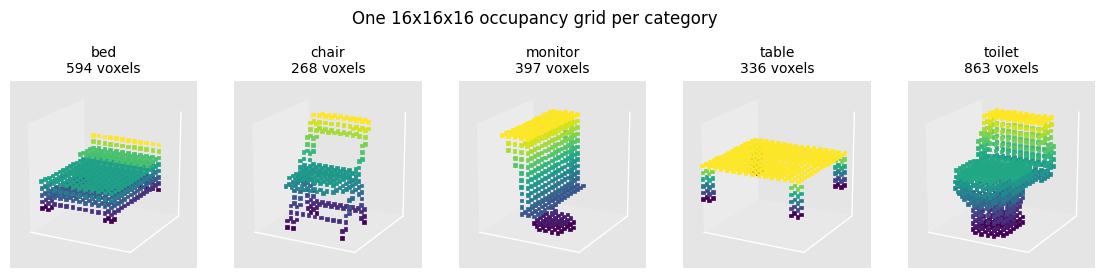

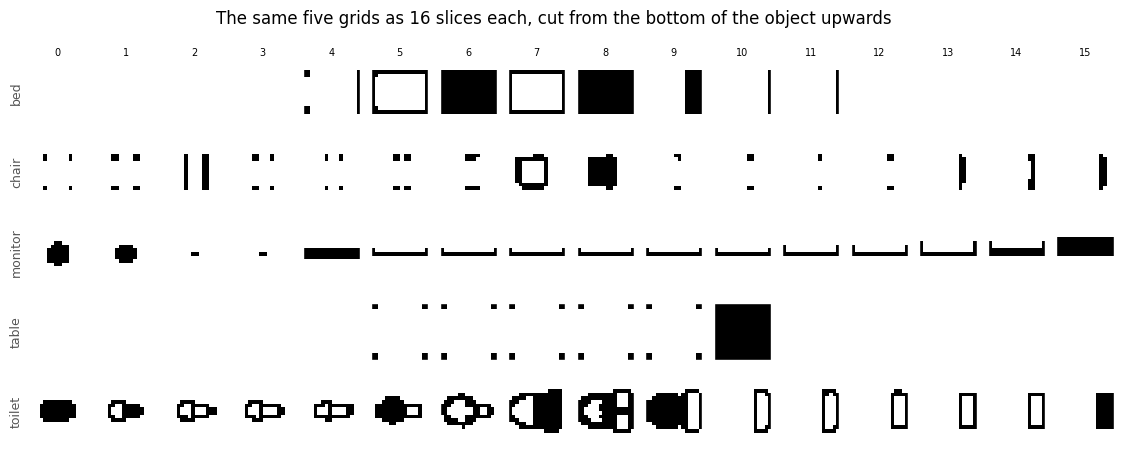

In [27]:
fig = plt.figure(figsize=(14, 3.4))

for k, name in enumerate(shape_names):
    sample = np.where(v_train_labels == k)[0][0]
    occupied = np.argwhere(V_train[sample] > 0)
    a = fig.add_subplot(1, 5, k + 1, projection='3d')
    a.scatter(occupied[:, 0], occupied[:, 1], occupied[:, 2],
              c=occupied[:, 2], cmap='viridis', s=7, marker='s', depthshade=False)
    a.set_xlim(0, grid_size); a.set_ylim(0, grid_size); a.set_zlim(0, grid_size)
    a.set_box_aspect((1, 1, 1))
    a.set_xticks([]); a.set_yticks([]); a.set_zticks([])
    a.set_title(f'{name}\n{int(V_train[sample].sum())} voxels', fontsize=10)
    a.view_init(elev=18, azim=-62)
    a.grid(False)

plt.suptitle(f'One {grid_size}x{grid_size}x{grid_size} occupancy grid per category')
plt.show()

fig, ax = plt.subplots(5, 16, figsize=(14, 5))

for k, name in enumerate(shape_names):
    sample = np.where(v_train_labels == k)[0][0]
    for z in range(grid_size):
        a = ax[k, z]
        a.imshow(V_train[sample][:, :, z], cmap='Greys', vmin=0, vmax=1)
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
        if k == 0:
            a.set_title(z, fontsize=7)
    ax[k, 0].set_ylabel(name, fontsize=9)

plt.suptitle('The same five grids as 16 slices each, cut from the bottom of the object upwards')
plt.show()

## Max pooling

Section 1 had no pooling layer because a $2\times2\times2$ pool on a $(2, 2, 3)$ response grid would
have returned one number per filter and thrown away eleven of twelve responses. Here the response
grid is $14^3$, so pooling does what it is meant to do: it takes each disjoint $2\times2\times2$
block of the ReLU output and keeps only the largest value in it,

$$P[d,i,j,f] = \max_{a,b,c \in \{0,1\}} R[2d+a,\; 2i+b,\; 2j+c,\; f]$$

which turns $14^3 = 2{,}744$ positions per filter into $7^3 = 343$, a factor of eight. It also makes
the response insensitive to a shift of one voxel, which matters when the input is a surface that
lands on a slightly different voxel depending on where the model happened to be centred.

`maxpool3d_forward` does this by reshaping the $(n, 14, 14, 14, f)$ array so that the eight members
of a block sit along one axis, then taking `max` and `argmax` along it. The `argmax` is the part that
matters for the backward pass. Pooling passes gradient only to the value that won its block, and in
a sparse occupancy grid ties are common - whole blocks of the ReLU output are exactly zero, since
the input there is all-empty space. Splitting the gradient between tied winners, or giving it to all
of them, would multiply the gradient by up to eight in exactly those blocks. `argmax` picks one
index and the recorded index is the only one that receives anything, which is what makes the
finite-difference check below pass.

In [28]:
def maxpool3d_forward(A):
    n, d, h, w, f = A.shape

    # put the eight members of each 2x2x2 block along a single axis
    blocks = A.reshape(n, d // 2, 2, h // 2, 2, w // 2, 2, f)
    blocks = blocks.transpose(0, 1, 3, 5, 2, 4, 6, 7).reshape(n, d // 2, h // 2, w // 2, 8, f)

    return blocks.max(axis=4), blocks.argmax(axis=4)


def maxpool3d_backward(dout, winner, shape):
    n, d, h, w, f = shape

    dblocks = np.zeros((n, d // 2, h // 2, w // 2, 8, f))
    # only the recorded winner of each block receives gradient
    np.put_along_axis(dblocks, winner[:, :, :, :, None, :], dout[:, :, :, :, None, :], axis=4)

    dblocks = dblocks.reshape(n, d // 2, h // 2, w // 2, 2, 2, 2, f)
    return dblocks.transpose(0, 1, 4, 2, 5, 3, 6, 7).reshape(shape)


check_input = np.random.default_rng(0).random((2, 4, 4, 4, 3))
pooled, winner = maxpool3d_forward(check_input)
back = maxpool3d_backward(np.ones_like(pooled), winner, check_input.shape)

print('pool input :', check_input.shape)
print('pool output:', pooled.shape)
print('largest value of one block:', check_input[0, :2, :2, :2, 0].max(),
      'kept as', pooled[0, 0, 0, 0, 0])
print('gradient entries set per block:', int(back.sum() / pooled[..., 0].size / 3),
      '- one of eight, as it should be')

pool input : (2, 4, 4, 4, 3)
pool output: (2, 2, 2, 2, 3)
largest value of one block: 0.8574042765875693 kept as 0.8574042765875693
gradient entries set per block: 1 - one of eight, as it should be


## The network on voxels

The size rule from Section 1 applies on all three axes here too:

$$(16, 16, 16) \xrightarrow{\;3\times3\times3\;} (16-3+1)^3 = (14, 14, 14)
\xrightarrow{\;\text{pool } 2\;} (7, 7, 7)$$

and the weight-count argument is the same one, only starker at this size. A $3\times3\times3$ filter
is **27 weights**, and that number is a property of the filter, not of the volume - the same 27
weights would slide over a $16^3$ grid or a $128^3$ one. A dense unit reading the $16^3$ grid
directly needs one weight per voxel, $16^3 = $ **4,096**, and at $128^3$ it would need 2,097,152.
The 8 filters here are 216 weights and they produce 8 full response maps of the whole volume.

The dense layer at the end is where the parameters actually are: $7^3 \times 8 = 2{,}744$ inputs to
5 classes is 13,720 weights against the convolution's 216. That imbalance is worth keeping in mind
when reading the accuracy below, and it is measured directly at the end of the section.

`VoxelCNN` is the same shape of class as `CNN_3D`, with the pooling layer inserted between the ReLU
and the flatten, and with the number of classes as a parameter.

In [29]:
class VoxelCNN:
    def __init__(self, grid=16, kernel=3, num_filters=8, num_classes=5,
                 learning_rate=0.05, seed=0):
        r = np.random.default_rng(seed)

        fan_in = kernel ** 3
        self.kernels = r.normal(0, np.sqrt(2 / fan_in), (num_filters, kernel, kernel, kernel))
        self.kernel_bias = np.zeros(num_filters)

        self.conv_side = grid - kernel + 1
        self.pool_side = self.conv_side // 2
        self.flat_size = self.pool_side ** 3 * num_filters

        self.weights = r.normal(0, np.sqrt(2 / self.flat_size), (self.flat_size, num_classes))
        self.bias = np.zeros(num_classes)
        self.learning_rate = learning_rate

    def forward(self, V):
        self.V = V
        self.conv = conv3d_forward(V, self.kernels, self.kernel_bias)
        self.relu = np.maximum(0, self.conv)
        self.pool, self.winner = maxpool3d_forward(self.relu)
        self.flat = self.pool.reshape(len(V), -1)
        self.scores = self.flat @ self.weights + self.bias
        return softmax(self.scores)

    def gradients(self, probs, y):
        n = len(y)

        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1
        dscores /= n

        dweights = self.flat.T @ dscores
        dbias = dscores.sum(axis=0)

        dpool = (dscores @ self.weights.T).reshape(self.pool.shape)
        drelu = maxpool3d_backward(dpool, self.winner, self.relu.shape)
        dconv = drelu * (self.conv > 0)
        dkernels, dkernel_bias = conv3d_backward(self.V, self.kernels, dconv)

        return dkernels, dkernel_bias, dweights, dbias

    def backward(self, probs, y):
        dkernels, dkernel_bias, dweights, dbias = self.gradients(probs, y)

        self.kernels -= self.learning_rate * dkernels
        self.kernel_bias -= self.learning_rate * dkernel_bias
        self.weights -= self.learning_rate * dweights
        self.bias -= self.learning_rate * dbias

    def predict(self, V):
        return self.forward(V).argmax(axis=1)


voxel_net = VoxelCNN()
print('convolution output:', (voxel_net.conv_side,) * 3, 'per filter')
print('after pooling     :', (voxel_net.pool_side,) * 3, 'per filter, flattened to',
      voxel_net.flat_size)
print('filter weights:', voxel_net.kernels.size, '+', voxel_net.kernel_bias.size, 'biases')
print('dense weights :', voxel_net.weights.size, '+', voxel_net.bias.size, 'biases')
print('total parameters:', voxel_net.kernels.size + voxel_net.kernel_bias.size
      + voxel_net.weights.size + voxel_net.bias.size)
print()
print('one 3x3x3 filter:', 3 ** 3, 'weights')
print('a dense unit on the raw grid:', 16 ** 3, 'weights')

convolution output: (14, 14, 14) per filter
after pooling     : (7, 7, 7) per filter, flattened to 2744
filter weights: 216 + 8 biases
dense weights : 13720 + 5 biases
total parameters: 13949

one 3x3x3 filter: 27 weights
a dense unit on the raw grid: 4096 weights


## Checking the derivatives again

The network in Section 1 had one differentiable path. This one has a pooling layer in the middle,
which routes gradient through a discrete choice, so the check is worth repeating rather than
assuming it carries over. The procedure is identical: move a weight by $\varepsilon = 10^{-5}$ each
way and compare

$$\frac{J(w + \varepsilon) - J(w - \varepsilon)}{2\varepsilon}$$

against what `gradients` reports. The five filter weights and five dense weights with the largest
gradients are checked, since a weight with a near-zero gradient would agree by accident.

Max pooling makes the loss piecewise linear rather than smooth, and at a point where two values in a
block are exactly equal the finite difference would straddle a kink and disagree. It does not happen
here: the ties in these grids are blocks that the ReLU has set entirely to zero, and a perturbation
of $10^{-5}$ leaves them at zero on both sides, so the winner does not change.

In [30]:
voxel_check = VoxelCNN(num_filters=4, learning_rate=0.0, seed=1)
V_batch, v_batch_labels = V_train[:8], v_train_labels[:8]

dkernels, _, dweights, _ = voxel_check.gradients(
    voxel_check.forward(V_batch), v_batch_labels)


def voxel_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = loss_of(voxel_check, V_batch, v_batch_labels)
    param[index] = original - eps
    down = loss_of(voxel_check, V_batch, v_batch_labels)
    param[index] = original
    return (up - down) / (2 * eps)


worst = 0.0
print(f'{"weight":24s} {"from gradients":>16s} {"measured":>16s}')
for index in largest(dkernels):
    analytic, measured = dkernels[index], voxel_slope(voxel_check.kernels, index)
    worst = max(worst, abs(analytic - measured))
    print(f'kernel {str(index):17s} {analytic:16.8f} {measured:16.8f}')
for index in largest(dweights):
    analytic, measured = dweights[index], voxel_slope(voxel_check.weights, index)
    worst = max(worst, abs(analytic - measured))
    print(f'dense  {str(index):17s} {analytic:16.8f} {measured:16.8f}')

print()
print(f'largest disagreement: {worst:.3e}')

weight                     from gradients         measured


kernel (2, 1, 2, 0)           -0.48383864      -0.48383864
kernel (2, 2, 2, 0)           -0.46477803      -0.46477803


kernel (2, 0, 2, 0)           -0.43027985      -0.43027985


kernel (2, 2, 2, 1)           -0.40553714      -0.40553714


kernel (2, 1, 2, 1)           -0.39055320      -0.39055320


dense  (1361, 0)              -0.79895049      -0.79895049
dense  (1184, 0)              -0.72996793      -0.72996793


dense  (204, 0)               -0.71762453      -0.71762453


dense  (988, 0)               -0.71329882      -0.71329882
dense  (745, 0)               -0.70392572      -0.70392572

largest disagreement: 9.326e-12


Eight decimal places again, on gradients of size 0.4 to 0.8, so the pooling backward pass routes the
gradient to the same places the loss does.

## Training

Twenty-five passes over the 650 training models in batches of 32. Everything about the loop is the
same as Section 1 except the learning rate, which is 0.05 rather than 0.1 because the flattened
vector here is 2,744 numbers rather than 192 and the dense gradients are correspondingly larger.

In [31]:
started = time.time()
voxel_net = VoxelCNN(grid=grid_size, kernel=3, num_filters=8, num_classes=5,
                     learning_rate=0.05, seed=0)

v_train_loss, v_test_loss, v_train_acc, v_test_acc = [], [], [], []

for epoch in range(25):
    order = np.random.default_rng(epoch).permutation(len(V_train))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        probs = voxel_net.forward(V_train[batch])
        voxel_net.backward(probs, v_train_labels[batch])

    tl, ta = loss_and_accuracy(voxel_net, V_train, v_train_labels)
    vl, va = loss_and_accuracy(voxel_net, V_test, v_test_labels)
    v_train_loss.append(tl); v_train_acc.append(ta)
    v_test_loss.append(vl); v_test_acc.append(va)

    print(f'epoch {epoch+1:2d}  train loss {tl:.4f} acc {ta:.4f}  |  '
          f'test loss {vl:.4f} acc {va:.4f}  |  {time.time() - started:5.1f} s')

print()
print(f'training took {time.time() - started:.1f} seconds')
print(f'final test accuracy    : {v_test_acc[-1]:.4f}')
print(f'majority class baseline: {voxel_baseline:.4f}')

epoch  1  train loss 0.2931 acc 0.9046  |  test loss 0.3251 acc 0.8640  |   18.0 s


epoch  2  train loss 0.1955 acc 0.9292  |  test loss 0.2388 acc 0.9200  |   34.9 s


epoch  3  train loss 0.1329 acc 0.9615  |  test loss 0.1806 acc 0.9400  |   51.8 s


epoch  4  train loss 0.0713 acc 0.9846  |  test loss 0.1367 acc 0.9520  |   74.7 s


epoch  5  train loss 0.0584 acc 0.9846  |  test loss 0.1537 acc 0.9400  |   97.1 s


...

epoch 21  train loss 0.0094 acc 0.9985  |  test loss 0.1240 acc 0.9640  |  373.8 s


epoch 22  train loss 0.0076 acc 1.0000  |  test loss 0.1189 acc 0.9600  |  386.3 s


epoch 23  train loss 0.0073 acc 1.0000  |  test loss 0.1185 acc 0.9600  |  400.8 s


epoch 24  train loss 0.0070 acc 1.0000  |  test loss 0.1202 acc 0.9600  |  416.4 s


epoch 25  train loss 0.0064 acc 1.0000  |  test loss 0.1195 acc 0.9600  |  431.9 s

training took 431.9 seconds
final test accuracy    : 0.9600
majority class baseline: 0.2000


The curves, drawn the same way as in Section 1.

The gap here is much wider than it was on Landsat. Training accuracy reaches 1.0 while test accuracy
settles a few points lower, which is what 650 models against 13,949 parameters produces. The test
loss stops falling long before the training loss does, and nothing after that point is being learned
that generalises.

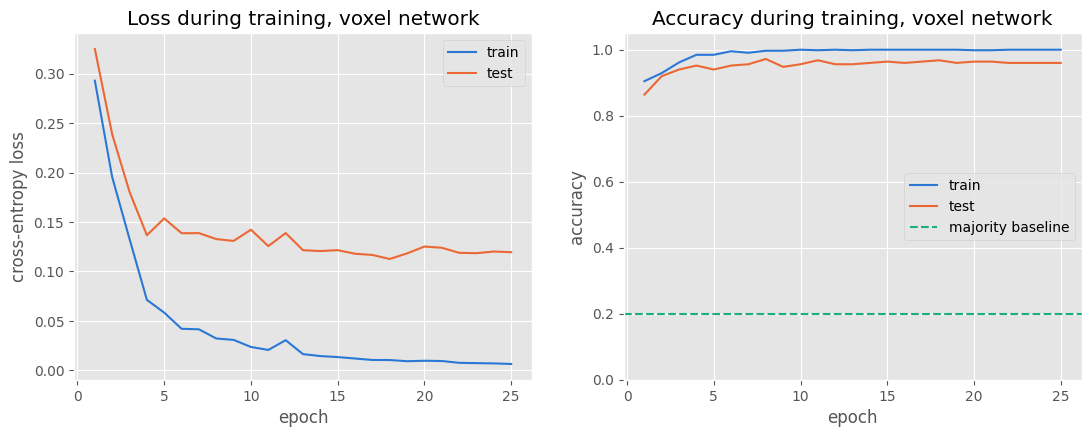

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(v_train_loss) + 1)

ax[0].plot(epochs, v_train_loss, color=blue, label='train')
ax[0].plot(epochs, v_test_loss, color=orange, label='test')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('cross-entropy loss')
ax[0].set_title('Loss during training, voxel network')
ax[0].legend()

ax[1].plot(epochs, v_train_acc, color=blue, label='train')
ax[1].plot(epochs, v_test_acc, color=orange, label='test')
ax[1].axhline(voxel_baseline, color=green, linestyle='--', label='majority baseline')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.0, 1.05)
ax[1].set_title('Accuracy during training, voxel network')
ax[1].legend()

plt.show()

## Where the voxel mistakes are

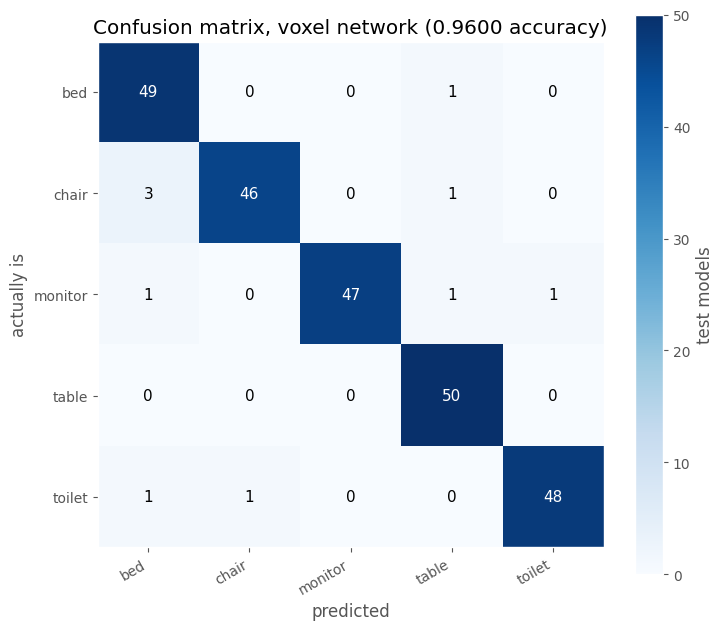

bed       :  49 of  50 correct (0.980)
chair     :  46 of  50 correct (0.920)
monitor   :  47 of  50 correct (0.940)
table     :  50 of  50 correct (1.000)
toilet    :  48 of  50 correct (0.960)


In [33]:
voxel_predictions = voxel_net.predict(V_test)

voxel_table = np.zeros((5, 5), dtype=int)
for true, guess in zip(v_test_labels, voxel_predictions):
    voxel_table[true, guess] += 1

plt.figure(figsize=(7.5, 6.5))
plt.imshow(voxel_table, cmap='Blues')
for i in range(5):
    for j in range(5):
        plt.text(j, i, voxel_table[i, j], ha='center', va='center', fontsize=11,
                 color='white' if voxel_table[i, j] > voxel_table.max() / 2 else 'black')
plt.xticks(range(5), shape_names, rotation=30, ha='right')
plt.yticks(range(5), shape_names)
plt.xlabel('predicted'); plt.ylabel('actually is')
plt.title(f'Confusion matrix, voxel network '
          f'({(voxel_predictions == v_test_labels).mean():.4f} accuracy)')
plt.colorbar(label='test models')
plt.grid(False)
plt.tight_layout()
plt.show()

for i in range(5):
    print(f'{shape_names[i]:10s}: {voxel_table[i, i]:3d} of {voxel_table[i].sum():3d} correct '
          f'({voxel_table[i, i] / voxel_table[i].sum():.3f})')

## What that number is and is not

The accuracy is well above the 0.2 baseline, and it is also higher than a single convolutional layer
on 650 coarse voxel grids has any right to be on the full benchmark. Both parts of that need saying
plainly.

The reason it is this high is that **the models are canonically aligned**. Every mesh in ModelNet10
is stored upright and facing a consistent direction, so after normalising into the unit cube a bed
occupies a particular region of the grid and a monitor occupies a different one, every time. Absolute
position is therefore informative on its own, and much of the problem is solved before any filter is
applied. The ablation below measures how much.

The reason it is not higher, and would drop on the full benchmark, is the other three points:

- **Coarse voxelisation destroys the fine geometry.** At $16^3$ the thin parts - slats, legs, a
  toilet's rim - are one voxel wide or gone. What survives is the gross silhouette, which is enough
  to separate a bed from a monitor and not enough to separate a table from a desk. The two hardest
  pairs in this benchmark, table against desk and night stand against dresser, are not in this
  subset at all; adding them would take a chunk off this number for a reason that has nothing to do
  with the network.
- **Surface grids are sparse.** 86% empty, and the occupied part is a shell. Most of the 2,744
  filter positions per volume look at nothing.
- **One convolutional layer, 650 models.** A single $3\times3\times3$ layer sees a $3^3$
  neighbourhood, and after pooling the dense layer sees $7^3$ positions of that. There is no second
  layer to compose those local responses into anything larger, and with 650 training models the
  training accuracy reaches 1.0 well before the test accuracy stops moving.

The errors that do occur follow the geometry. Only ten of the 250 test models are wrong, and the
largest single group is three chairs called beds - what survives voxelisation of a chair is a
horizontal seat with a vertical panel behind it, and what survives of a bed is a horizontal slab
with a headboard, so a wide low armchair and a bed differ mainly in proportions, which is the thing
that normalising by the largest extent preserves but coarse binning blurs. No table is missed, 50
of 50, though three models from other categories are called tables: a flat top on four thin legs is
unlike anything else in this subset - which is exactly why desk, the category built to be
confusable with it, was left out.

## Is the convolution earning its place

The same question as the centre-pixel ablation in Section 1, asked here: the alignment argument
above says a lot of this problem is solvable from absolute voxel positions alone, so the comparison
to make is against a model that has *only* absolute positions - a dense softmax layer reading the
4,096 raw voxels directly, with no convolution and no pooling. Same optimiser, same batch size, same
number of epochs, same learning rate.

$$p = \mathrm{softmax}(W^\top v + b), \qquad W \in \mathbb{R}^{4096 \times 5}$$

The gap between the two is what the convolution and the pooling add over reading the grid off
position by position.

dense-only parameters   : 20485
convolutional parameters: 13949

dense layer on the raw 4096 voxels: 0.9240
convolution, pooling, dense       : 0.9600
majority class baseline           : 0.2000

the convolution and pooling are worth +0.0360


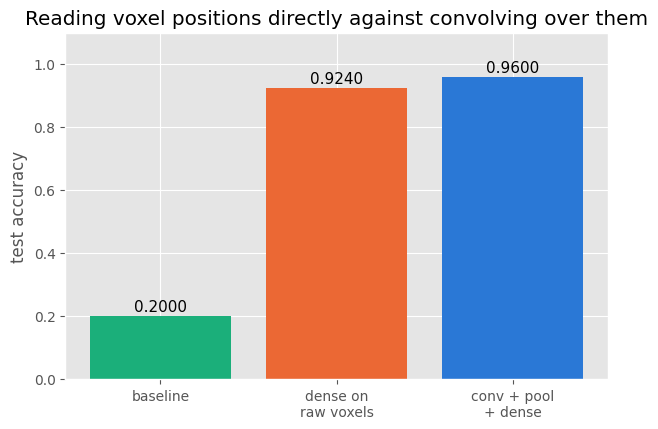

In [34]:
flat_train = V_train.reshape(len(V_train), -1)
flat_test = V_test.reshape(len(V_test), -1)

dense_rng = np.random.default_rng(0)
dense_weights = dense_rng.normal(0, np.sqrt(2 / flat_train.shape[1]), (flat_train.shape[1], 5))
dense_bias = np.zeros(5)

for epoch in range(25):
    order = np.random.default_rng(epoch).permutation(len(flat_train))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        block = flat_train[batch]
        probs = softmax(block @ dense_weights + dense_bias)
        dscores = probs.copy()
        dscores[np.arange(len(batch)), v_train_labels[batch]] -= 1
        dscores /= len(batch)
        dense_weights -= 0.05 * (block.T @ dscores)
        dense_bias -= 0.05 * dscores.sum(axis=0)

dense_only = (softmax(flat_test @ dense_weights + dense_bias).argmax(axis=1)
              == v_test_labels).mean()
conv_acc = v_test_acc[-1]

print('dense-only parameters   :', dense_weights.size + dense_bias.size)
print('convolutional parameters:', voxel_net.kernels.size + voxel_net.kernel_bias.size
      + voxel_net.weights.size + voxel_net.bias.size)
print()
print(f'dense layer on the raw 4096 voxels: {dense_only:.4f}')
print(f'convolution, pooling, dense       : {conv_acc:.4f}')
print(f'majority class baseline           : {voxel_baseline:.4f}')
print()
print(f'the convolution and pooling are worth {conv_acc - dense_only:+.4f}')

plt.figure(figsize=(7, 4.5))
plt.bar(['baseline', 'dense on\nraw voxels', 'conv + pool\n+ dense'],
        [voxel_baseline, dense_only, conv_acc], color=[green, orange, blue])
for x, value in enumerate([voxel_baseline, dense_only, conv_acc]):
    plt.text(x, value + 0.015, f'{value:.4f}', ha='center', fontsize=11)
plt.ylabel('test accuracy')
plt.ylim(0, 1.1)
plt.title('Reading voxel positions directly against convolving over them')
plt.show()

The dense layer on raw voxels already does well, which confirms the alignment argument: on
canonically aligned models, *where* a voxel is occupied carries most of the class information, and a
linear map over positions can pick that up. The convolution adds a few points on top, and it gets
there with fewer parameters in total, not more: 13,949 against the dense model's 20,485, because
pooling leaves its dense layer reading 2,744 numbers rather than 4,096.

The distinction worth drawing is what each would do to a rotated or shifted model. The dense layer
has one weight per absolute voxel and would be wrong immediately. The convolution recognises the
same local arrangement wherever it appears, and the pooling makes it insensitive to a one-voxel
shift. That robustness is not measured by this test set, because this test set is aligned too.

## One voxel model through the network

The same walkthrough as Section 1, on the larger volume where each stage has room to show something.
One test model is pushed through the trained network and every intermediate array is drawn. The
input is shown twice, as the 3D scatter and as its 16 slices; everything after is a slice grid, and
the shrinkage $16 \to 14 \to 7$ is directly visible as the slices getting fewer and smaller.

input grid       : (16, 16, 16) - 316 occupied voxels
after convolution: (14, 14, 14, 8) = (14, 14, 14, filter)
after ReLU       : (14, 14, 14, 8)  - 5711 of 21952 clipped to zero
after pooling    : (7, 7, 7, 8) = (7, 7, 7, filter)
flattened        : (2744,)

true class     : chair
predicted class: chair with probability 1.0000


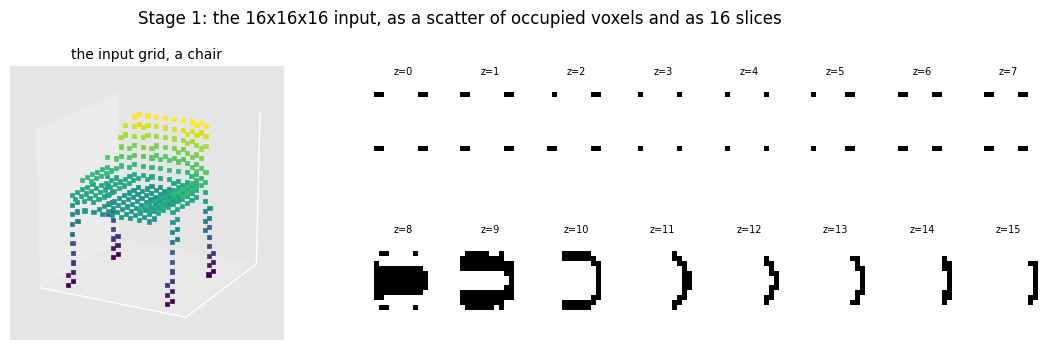

In [35]:
voxel_walk = int(np.where((v_test_labels == 1) & (voxel_predictions == 1))[0][0])
voxel_cube = V_test[voxel_walk]

walk_out = voxel_net.forward(V_test[voxel_walk:voxel_walk + 1])[0]
v_conv = voxel_net.conv[0]
v_relu = voxel_net.relu[0]
v_pool = voxel_net.pool[0]

print('input grid       :', voxel_cube.shape, '-', int(voxel_cube.sum()), 'occupied voxels')
print('after convolution:', v_conv.shape, '= (14, 14, 14, filter)')
print('after ReLU       :', v_relu.shape, end='  ')
print(f'- {int((v_relu == 0).sum())} of {v_relu.size} clipped to zero')
print('after pooling    :', v_pool.shape, '= (7, 7, 7, filter)')
print('flattened        :', voxel_net.flat[0].shape)
print()
print('true class     :', shape_names[v_test_labels[voxel_walk]])
print('predicted class:', shape_names[int(walk_out.argmax())],
      f'with probability {walk_out.max():.4f}')

fig = plt.figure(figsize=(12, 4))

a = fig.add_subplot(1, 3, 1, projection='3d')
occupied = np.argwhere(voxel_cube > 0)
a.scatter(occupied[:, 0], occupied[:, 1], occupied[:, 2],
          c=occupied[:, 2], cmap='viridis', s=9, marker='s', depthshade=False)
a.set_xlim(0, grid_size); a.set_ylim(0, grid_size); a.set_zlim(0, grid_size)
a.set_box_aspect((1, 1, 1))
a.set_xticks([]); a.set_yticks([]); a.set_zticks([])
a.set_title(f'the input grid, a {shape_names[v_test_labels[voxel_walk]]}', fontsize=10)
a.view_init(elev=18, azim=-62)
a.grid(False)

slices = fig.add_gridspec(2, 8, left=0.42, right=0.99, top=0.85, bottom=0.15,
                          wspace=0.1, hspace=0.3)
for z in range(grid_size):
    s = fig.add_subplot(slices[z // 8, z % 8])
    s.imshow(voxel_cube[:, :, z], cmap='Greys', vmin=0, vmax=1)
    s.set_title(f'z={z}', fontsize=7)
    s.set_xticks([]); s.set_yticks([]); s.grid(False)

plt.suptitle('Stage 1: the 16x16x16 input, as a scatter of occupied voxels and as 16 slices')
plt.show()

**Stages 2, 3 and 4.** One filter's output through the three stages, drawn as slices along the same
axis as the input above. The first two rows are the 14 convolution slices before the activation, on
a diverging scale so negative responses show as blue; the next two rows are the same after the ReLU,
on the same scale, so every square that was blue is now white; the last row is the 7 slices left
after $2\times2\times2$ pooling.

The three shrinkages are all visible at once. Sixteen slices become fourteen because the filter
needs three slices to sit in, and each remaining slice is $14\times14$ rather than $16\times16$ for
the same reason on the other two axes. Fourteen slices become seven because the pool takes them in
pairs, and each slice halves in the other two directions too - eight values in, one out - which is
why the squares in the last row are visibly coarser than the ones above them.

The response is thicker than the input. A filter reaches one voxel in every direction, so it returns
something non-zero at every position whose $3\times3\times3$ neighbourhood contains at least one
occupied voxel: a shell around the surface rather than the surface itself. Further out than that the
patch under the filter is all zeros and the response is just the bias, which trained to within 0.1
of zero for every filter, so the empty part of the volume comes out flat and the ReLU leaves it
flat. The chair is legible in the response slices, and what the filter has actually marked is where
the surface is, not what it is made of.

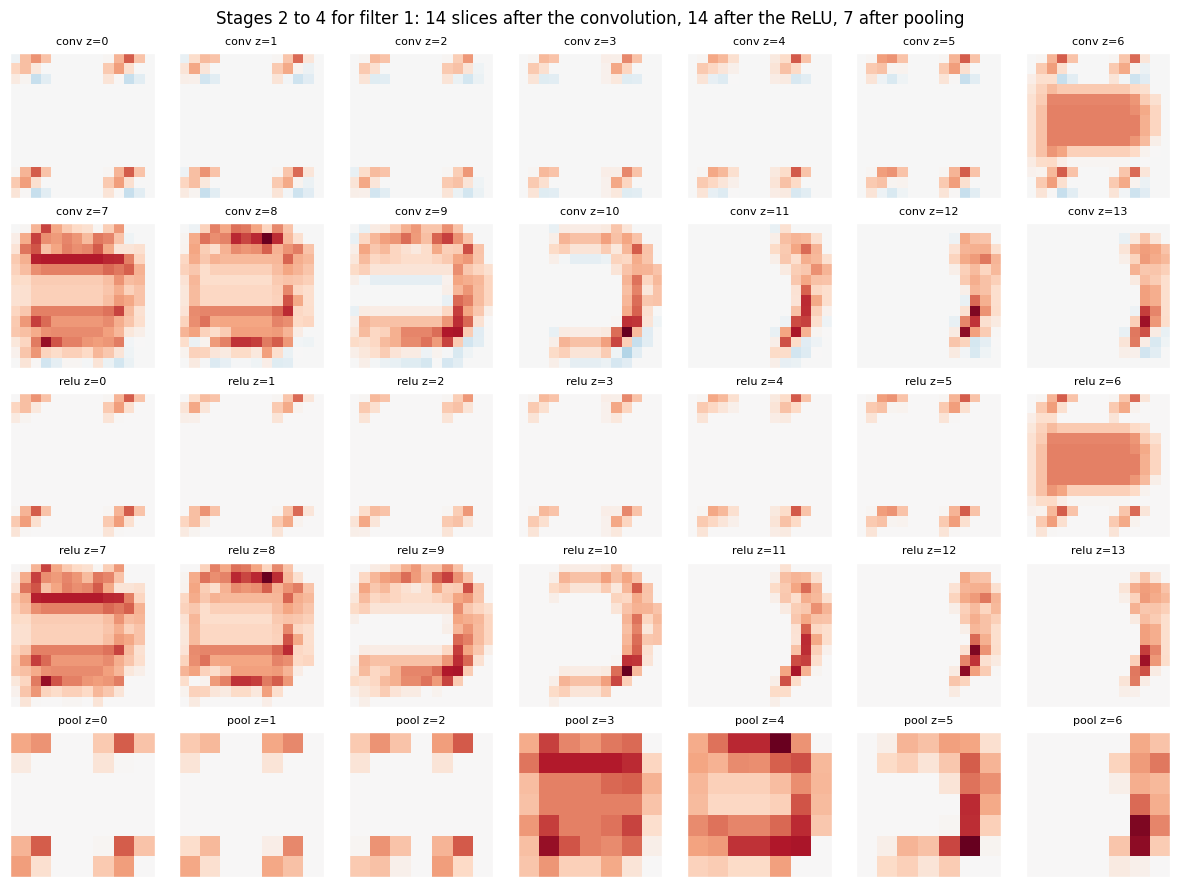

filter 1: 0.630 of its responses were clipped to zero by the ReLU
pooling kept 343 of 2744 values


In [36]:
top_filter = int(np.abs(v_conv).max(axis=(0, 1, 2)).argmax())

fig, ax = plt.subplots(5, 7, figsize=(12, 9))

limit = np.abs(v_conv[:, :, :, top_filter]).max()
for z in range(14):
    a = ax[z // 7, z % 7]
    a.imshow(v_conv[:, :, z, top_filter], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a.set_title(f'conv z={z}', fontsize=8)

for z in range(14):
    a = ax[2 + z // 7, z % 7]
    a.imshow(v_relu[:, :, z, top_filter], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a.set_title(f'relu z={z}', fontsize=8)

for z in range(7):
    a = ax[4, z]
    a.imshow(v_pool[:, :, z, top_filter], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a.set_title(f'pool z={z}', fontsize=8)

for row in ax:
    for a in row:
        a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle(f'Stages 2 to 4 for filter {top_filter}: '
             f'14 slices after the convolution, 14 after the ReLU, 7 after pooling')
plt.tight_layout()
plt.show()

print(f'filter {top_filter}: {(v_relu[:, :, :, top_filter] == 0).mean():.3f} of its responses '
      f'were clipped to zero by the ReLU')
print(f'pooling kept {v_pool[:, :, :, top_filter].size} of '
      f'{v_relu[:, :, :, top_filter].size} values')

## The learned 3x3x3 filters

Each of the 8 filters is a $3\times3\times3$ cube of weights, drawn below as its three depth slices,
on a scale shared across all of them. Dark is positive and light is negative, the same convention as
the Landsat filters above.

A filter with all three slices alike responds to occupancy in a small ball regardless of how it is
arranged - effectively a local density count. A filter whose slices differ responds to a change
along that axis, which on this data means a surface: occupied on one side and empty on the other is
precisely what the boundary of an object looks like in an occupancy grid. Those are the filters
doing the geometric work, and the printed number under the figure is how far each filter's slices
differ from each other.

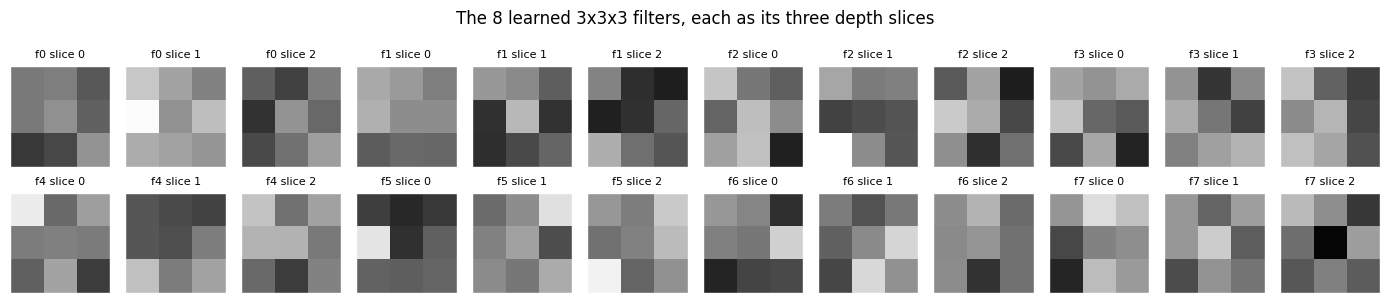

how much each filter varies across its three slices (mean absolute deviation):
[0.184 0.193 0.224 0.157 0.188 0.232 0.175 0.192]


In [37]:
fig, ax = plt.subplots(2, 12, figsize=(14, 3.2))

limit = np.abs(voxel_net.kernels).max()
for f in range(len(voxel_net.kernels)):
    for d in range(3):
        a = ax[f // 4, (f % 4) * 3 + d]
        a.imshow(voxel_net.kernels[f, d], cmap='gray_r', vmin=-limit, vmax=limit)
        a.set_title(f'f{f} slice {d}', fontsize=8)
        a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The 8 learned 3x3x3 filters, each as its three depth slices')
plt.tight_layout()
plt.show()

spread = np.abs(voxel_net.kernels - voxel_net.kernels.mean(axis=1, keepdims=True)).mean(axis=(1, 2, 3))
print('how much each filter varies across its three slices (mean absolute deviation):')
print(np.round(spread, 3))

## Summary of Section 2

- The Landsat cube is $3\times3\times4$, which is enough to demonstrate a 3D convolution and not
  enough to watch one work on a shape. ModelNet10 is genuinely volumetric: 4,899 CAD meshes in 10
  categories, of which 900 models in 5 categories - bed, chair, monitor, table, toilet - were used
  here, 130 train and 50 test each, at $16^3$. Every mesh parsed; none was malformed.
- The `.OFF` parser and the voxeliser are written here. A mesh becomes a grid by normalising into
  the unit cube, sampling 20,000 points over its surface with triangles drawn in proportion to
  their cross-product area and points placed by the barycentric map with the $\sqrt{r_1}$ that makes
  it area-uniform, and binning the points with
  $v = \mathrm{clip}(\lfloor (x + 0.5)N \rfloor, 0, N-1)$. Past about 20,000 points the occupied
  count stops rising, which is the check that the sampling is dense enough for the grid.
- The result is a **surface** occupancy grid: 13.7% of voxels occupied, about 562 of 4,096 per
  model, so 86% of every volume is empty and the occupied part is a hollow shell. Tables are the
  emptiest at 0.100 and toilets the fullest at 0.183. The array grows as $N^3$ while what is in it
  grows as $N^2$, which is why voxel convolution is expensive relative to the information present -
  all 2,744 filter positions get visited regardless.
- A $3\times3\times3$ filter is 27 weights whatever the volume is; a dense unit reading the $16^3$
  grid needs 4,096. The pooling layer that made no sense on Section 1's $(2,2,3)$ response grid
  belongs here, taking $14^3$ down to $7^3$, and its backward pass routes gradient by `argmax` so
  exactly one of the eight members of a block receives it - which matters because ties are common
  when whole blocks of the response are zero.
- The finite-difference check agrees with the analytic gradients to eight decimal places through the
  pooling layer as well, largest disagreement $9.3 \times 10^{-12}$.
- Test accuracy is 0.960 against a majority-class baseline of 0.200, with ten errors in 250 models,
  the largest group being three chairs called beds. That number is high for a single convolutional
  layer, and the reason is that ModelNet10 models are canonically aligned, so absolute position in
  the grid is informative on its own: a dense softmax layer reading the 4,096 raw voxels with no
  convolution at all reaches 0.924. The convolution and pooling add 3.6 points on top of that with
  fewer total parameters, and would add far more on data that was not pre-aligned.
- What holds the number down is the same list in reverse: $16^3$ binning erases anything thinner
  than a sixteenth of the object, the two deliberately confusable pairs in this benchmark - desk
  against table, night stand against dresser - are not in this subset, there is one convolutional
  layer rather than a stack, and 650 training models drive the training accuracy to 1.0 while the
  test loss stops improving after about five passes.

In [38]:
print(f'notebook runtime: {time.time() - notebook_started:.1f} seconds')

notebook runtime: 631.0 seconds
